# **Thông tin nhóm**
- Lớp: ML Labs 23KHDL1
- Nhóm: 3
- Sinh viên: 
    - 23127102 - Lê Quang Phúc
    - 23127212 - Nguyễn Quang Đăng Khoa
    - 23127241 - Đoàn Thành Phát
    - 23127332 - Trần Tiến Cường
    - 23127442 - Trầm Hữu Nhân


# **Model Implementation and Comparison**

## **1. Thư viện và thiết lập cấu hình chung**


In [5]:
import pandas as pd
import numpy as np
import ast
import re
import joblib
import warnings
import matplotlib.pyplot as plt
import time
import os

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBRanker
from sklearn.preprocessing import OneHotEncoder
from pathlib import Path
from typing import Tuple, List, Optional, Dict, Any
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

## **2. Model Architecture**

### 2.1. Paradigm
Hệ thống sử dụng Mô hình lai (Hybrid Recommender) là sự kết hợp giữa trích xuất ứng viên bằng `Content-Based Filtering` kết hợp với thuật toán học máy `XGBoost` để giải quyết cho hệ thống gợi ý và phát biểu lại dưới dạng bài toán Phân loại văn bản đa lớp (multi-class text classification).

### 2.2 Model
Hệ thống hoạt động theo mô hình Phễu 2 giai đoạn (Two-Stage Architecture):

1. **Giai đoạn 1 - Trích xuất ứng viên (Candidate Generation) bằng Content-Based Filtering:**
   * **Đầu vào:** Toàn bộ dữ liệu về địa điểm.
   * **Xử lý:** Sử dụng `TfidfVectorizer` để biểu diễn từ vựng và tính toán khoảng cách `Cosine Similarity` giữa câu truy vấn của người dùng với hồ sơ (profile) của từng địa điểm, để tìm các ứng viên có độ tương động với dữ liệu đầu vào.
   * **Đầu ra:** Top 100 ứng viên tiềm năng nhất. 

2. **Giai đoạn 2 - Học xếp hạng (XGBoost):**
   * **Đầu vào:** Top 100 ứng viên từ Giai đoạn 1.
   * **Xử lý:** Mô hình `XGBRanker` trích xuất thêm các đặc trưng đa chiều (Giá logarit, Danh mục One-hot, Điểm rating...) và tiến hành chấm điểm (scoring) lại từng ứng viên.
   * **Đầu ra:** Top 5 địa điểm có điểm số cao nhất tương ứng với câu mô tả đầu vào.

### 2.3 Pipeline

Bao gồm các bước sau:

* Tiền xử lý và chia tập dữ liệu
* Giai đoạn 1: Lọc thô bằng Content-Based Filtering (Candidate Generation)
* Giai đoạn 2: Xây dựng dữ liệu Xếp hạng 
* Đánh giá và huấn luyện trên toàn bộ dữ liệu
* Suy luận và hậu xử lý cho bài toán gợi ý

### 2.4 Độ phù hợp với dữ liệu/bài toán

Hệ thống này kết hợp 2 thuật toán để tận dụng tối đa dữ liệu hiện có:

* **Lí do chọn Content-Based Filtering (TF-IDF)** Thuật toán này cực kỳ nhanh và hiệu quả trong việc tìm kiếm sự tương đồng văn bản. Nó đóng vai trò như một "cái phễu" rộng, quét qua hàng chục ngàn địa điểm và lọc ra một danh sách các ứng viên tiềm năng có bình luận, mô tả khớp với từ khóa của người dùng.
* **Lí do chọn XGBoost (XGBRanker)** TF-IDF chỉ quan tâm đến văn bản mà bỏ qua các yếu tố cực kỳ quan trọng đối với khách du lịch như: Giá cả (`Price`), Điểm đánh giá (`Score`), và số lượng bình luận (`Nums_comments`). `XGBRanker` thuộc họ thuật toán Gradient Boosting, có khả năng kết hợp điểm tương tự văn bản với các dữ liệu dạng bảng (tabular data) này để tối ưu hóa trực tiếp thứ hạng (tối đa hóa chỉ số `NDCG`), giúp đưa ra kết quả cuối cùng chính xác và thực tế nhất.



## **3. Tiền xử lý và Chiến lược chia tập dữ liệu**
Mục tiêu của giai đoạn này là làm sạch dữ liệu thô, biến đổi cấu trúc dữ liệu để phù hợp với mô hình học máy và chia tách dữ liệu một cách an toàn nhằm phục vụ quá trình huấn luyện và đánh giá khách quan nhất. Toàn bộ quy trình này được đóng gói gọn gàng trong class `DataPreprocessor`

### 3.1 Trích xuất nội dung bình luận

Từ cột dữ liệu bình luận gốc được bóc tách và phân rã thành một danh sách các câu văn bản (`comment_parsed`). 

### 3.2 Tạo comment cho các địa điểm thiếu dữ liệu 

Nếu một địa điểm bị thiếu dữ liệu bình luận, nhóm sẽ lấy các thông tin từ dòng đó để ghép thành một câu miêu tả cơ bản như sau:`[Category] + giá từ + [Price_min] + tại + [Address]`.

### 3.3 Tái cấu trúc bộ dữ liệu
Dữ liệu gốc có cấu trúc là "1 địa điểm - nhiều bình luận", để mô hình có thể học từng ngữ cảnh một cách độc lập, nhóm sử dụng hàm `explode` để phân rã thành "1 địa điểm - 1 bình luận" theo từng dòng. 

### 3.4 Chiến lược chia tập dữ liệu
Do đặc thù của dữ liệu thực tế tồn tại hiện tượng mất cân bằng, có những địa điểm thu thập được rất ít bình luận (dưới 6 bình luận). Nếu chia ngẫu nhiên, các mẫu này có thể rơi vào tập `Validation` hoặc `Test` khiến mô hình mất đi dữ liệu để học, hoặc gây lỗi chia dữ liệu. 

Để giải quyết các vấn đề trên, nhóm đã thực hiện chiến lược phân chia dữ liệu như sau:
- Tách riêng các địa điểm có ít hơn 6 bình luận (`rare_location`).
- Sau khi dữ liệu hiếm bị loại ra, phần dữ liệu còn lại thay vì được chia ngẫu nhiên đơn thuần thì nhóm sẽ áp dụng lấy mẫu phân từng (`stratify=y`). Có nghĩa là mỗi khi chia ra theo tỷ lệ `70% Train - 15% Validation - 15% Test` nhưng vẫn đảm bảo được số lượng mẫu đồng đều trên cả 3 tập đối với mỗi địa điểm khác nhau.

In [9]:
class DataPreprocessor:
    def __init__(self, file_path: str):
        self.file_path = file_path
        self.df_raw: Optional[pd.DataFrame] = None
        self.df_exploded: Optional[pd.DataFrame] = None
        self.df_train: Optional[pd.DataFrame] = None
        self.df_valid: Optional[pd.DataFrame] = None
        self.df_test: Optional[pd.DataFrame] = None
        
    def _parse_comments_string(self, comments_str: str) -> List[str]:
        def _clean_comment(value: object) -> str:
            text = str(value).strip()
            text = text.replace('\n', ' ').replace('\\n', ' ')
            text = re.sub(r'\s+', ' ', text).strip()
            return text

        if isinstance(comments_str, (list, tuple)):
            return [c for c in (_clean_comment(x) for x in comments_str) if c]

        if comments_str is None:
            return []

        comments_text = str(comments_str).strip()
        if comments_text == '' or comments_text == '[]' or comments_text.lower() == 'nan':
            return []

        try:
            parsed = ast.literal_eval(comments_text)
            if isinstance(parsed, (list, tuple)):
                cleaned = []
                for item in parsed:
                    if item is None:
                        continue
                    item_text = _clean_comment(item)
                    if item_text.startswith('{') and item_text.endswith('}'):
                        item_text = _clean_comment(item_text[1:-1])
                    if item_text:
                        cleaned.append(item_text)
                return cleaned
        except (ValueError, SyntaxError, TypeError):
            pass

        matches = re.findall(r'\{(.*?)\}', comments_text, flags=re.DOTALL)
        if matches:
            return [c for c in (_clean_comment(m) for m in matches) if c]

        fallback = comments_text.strip('[]').strip()
        if fallback.startswith('{') and fallback.endswith('}'):
            fallback = fallback[1:-1]
        fallback = _clean_comment(fallback)

        return [fallback] if fallback else []
    
    def _generate_synthetic_comment(self, row: pd.Series) -> str:
        category = str(row.get('Category', 'Unknown'))
        price_min = str(row.get('Price_min', 0))
        address = str(row.get('Address', 'Unknown'))
        
        return f"{category} giá từ {price_min} VND tại {address}"
    
    def step1_explode_comments(self) -> pd.DataFrame:
        self.df_raw = pd.read_csv(self.file_path)
        
        df = self.df_raw.copy()
        
        df['Comments_parsed'] = df['Comments'].apply(self._parse_comments_string)
        
        total_comments = df['Comments_parsed'].apply(len).sum()
        
        df_exploded = df.explode('Comments_parsed', ignore_index=True)
        
        df_exploded = df_exploded.rename(columns={'Comments_parsed': 'Comment'})
        df_exploded = df_exploded.drop(columns=['Comments'])
        
        self.df_exploded = df_exploded

        return df_exploded
    
    def step2_fill_missing_comments(self) -> pd.DataFrame:
        if self.df_exploded is None:
            raise ValueError("Must run step 1 before running this step!")
        
        df = self.df_exploded.copy()
        
        missing_mask = df['Comment'].isna() | (df['Comment'] == '') | (df['Comment'].apply(lambda x: x == [] if isinstance(x, list) else False))
        num_missing = missing_mask.sum()
        
        if num_missing > 0:
            df.loc[missing_mask, 'Comment'] = df.loc[missing_mask].apply(
                self._generate_synthetic_comment, axis=1
            )
        
        remaining_missing = df['Comment'].isna().sum()
        
        self.df_exploded = df

        return df
    
    def step3_custom_splitting(self) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        if self.df_exploded is None:
            raise ValueError("Must run step 1and step 2 before splitting!")
        
        df = self.df_exploded.copy()
        
        comment_counts = df.groupby('Name').size()
        rare_locations = comment_counts[comment_counts < 6].index
        mask_rare = df['Name'].isin(rare_locations)

        df_train_rare = df[mask_rare]
        df_rest = df[~mask_rare]

        if df_rest.empty:
            self.df_train = df_train_rare.reset_index(drop=True)
            self.df_valid = pd.DataFrame()
            self.df_test = pd.DataFrame()
            return self.df_train, self.df_valid, self.df_test

        stratify_col = 'label_id' if 'label_id' in df_rest.columns else 'Name'
        y = df_rest[stratify_col]

        train_data, temp_data = train_test_split(
            df_rest,
            test_size=0.3,
            stratify=y,
            random_state=42
        )
        valid_data, test_data = train_test_split(
            temp_data,
            test_size=0.5,
            stratify=temp_data[stratify_col],
            random_state=42
        )

        if not df_train_rare.empty:
            train_data = pd.concat([train_data, df_train_rare], ignore_index=True)

        self.df_train = train_data.reset_index(drop=True)
        self.df_valid = valid_data.reset_index(drop=True)
        self.df_test = test_data.reset_index(drop=True)
        
        return self.df_train, self.df_valid, self.df_test
    
    def process(self) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        self.step1_explode_comments()
        self.step2_fill_missing_comments()
        self.step3_custom_splitting()
        self._print_final_summary()
        
        return self.df_train, self.df_valid, self.df_test
    
    def _print_final_summary(self):
        train_size = len(self.df_train) if self.df_train is not None else 0
        valid_size = len(self.df_valid) if self.df_valid is not None else 0
        test_size = len(self.df_test) if self.df_test is not None else 0
        total = train_size + valid_size + test_size
        
        print(f"Train {train_size:}")
        print(f"Validation: {valid_size:}")
        print(f"Test : {test_size:}")
        

In [10]:
preprocessor = DataPreprocessor("../data/processed_data.csv")
df_train, df_valid, df_test = preprocessor.process()

Train 97189
Validation: 20066
Test : 20067


## **4. Giai đoạn 1: Trích xuất ứng viên (Content-Based Filtering)**

Sau khi dữ liệu đã được làm sạch, hệ thống bước vào giai đoạn đầu tiên của kiến trúc Hybrid: **Content-Based Filtering (Lọc dựa trên nội dung)**. 

Mục tiêu của giai đoạn này đóng vai trò như một "cái phễu" lọc thô: Nhanh chóng thu hẹp không gian tìm kiếm từ hàng vạn địa điểm xuống còn một danh sách nhỏ (Top $K = 100$) các ứng viên tiềm năng nhất, dựa trên sự tương đồng về mặt ngữ nghĩa văn bản với truy vấn của người dùng.

Để làm được điều này, class `ContentBasedFilter` thực hiện các cơ chế cốt lõi sau:

### 4.1. Xây dựng Hồ sơ Địa điểm (Item Profiling)
Thay vì chỉ dùng tên địa điểm, hệ thống tạo ra một "hồ sơ văn bản" (text profile) toàn diện cho mỗi mục bằng cách ghép nối 3 trường thông tin: `Category` (Danh mục) + `Address` (Địa chỉ) + `Comment` (Bình luận của người dùng). Điều này giúp mô hình nắm bắt được cả thuộc tính tĩnh (vị trí, loại hình) lẫn trải nghiệm động (đánh giá từ khách hàng).

### 4.2. Vector hóa Văn bản bằng TF-IDF
Hệ thống sử dụng thuật toán `TfidfVectorizer` để chuyển đổi các hồ sơ văn bản và câu truy vấn của người dùng thành các vector số học dạng ma trận thưa (sparse matrix).
* **TF (Term Frequency):** Tần suất xuất hiện của từ khóa trong tài liệu.
* **IDF (Inverse Document Frequency):** Đánh trọng số cao cho các từ khóa hiếm/đặc trưng (ví dụ: "biển", "chùa") và giảm trọng số của các từ vô nghĩa xuất hiện quá nhiều.
* Tham số `sublinear_tf=True` được áp dụng để tránh việc các từ khóa lặp lại quá nhiều lần làm sai lệch kết quả.

### 4.3. Tính toán Độ tương tự (Cosine Similarity)
Khi có truy vấn mới (ví dụ: *"Tôi muốn tìm quán ăn hải sản"*), mô hình cũng vector hóa truy vấn này và tính toán khoảng cách góc (Cosine Similarity) giữa vector truy vấn với toàn bộ ma trận vector của các địa điểm. Các địa điểm có góc càng nhỏ (điểm Cosine càng gần 1) thì độ tương đồng càng cao.

### 4.4. Đánh giá Khả năng Trích xuất (Recall@K)
Vì đây chỉ là bước lọc thô, chỉ số đánh giá quan trọng nhất ở đây không phải là sắp xếp chính xác tuyệt đối, mà là **Recall@K** (Độ phủ). Hệ thống tính toán xem trong Top 100 ứng viên được chọn ra, có bao nhiêu phần trăm chứa đúng địa điểm mà người dùng thực sự muốn tìm (Ground Truth). Nếu Recall cao, Giai đoạn 2 (XGBoost) sẽ có nguồn dữ liệu đầu vào chất lượng để tinh chỉnh thứ hạng.

---

In [62]:
class ContentBasedFilter:
    """
    Class thực hiện Content-Based Filtering để tạo danh sách ứng viên (Candidate Generation).
    
    Bài toán:
    - Coi 1 Comment (bình luận) là 1 "Query" (nhu cầu/truy vấn của người dùng).
    - Coi Name (Tên địa điểm) là "Ground Truth Item" (địa điểm thực tế mà người dùng hướng tới).
    
    Cách hoạt động:
    1. Xây dựng Profile (Hồ sơ) cho mỗi Item (địa điểm) từ tập dữ liệu huấn luyện (train set).
    2. Sử dụng TF-IDF để chuyển đổi các Document (Hồ sơ dạng văn bản) thành các vector số học.
    3. Tính toán độ tương tự Cosine (Cosine Similarity) giữa vector query và các vector Item Profiles.
    4. Trả về Top K ứng viên có độ tương tự cao nhất.
    """
    
    def __init__(self, top_k: int = 100):
        """
        Khởi tạo đối tượng ContentBasedFilter.
        
        Args:
            top_k: Số lượng ứng viên tối đa trả về cho mỗi truy vấn.
        """
        self.top_k = top_k
        
        # Khởi tạo vectorizer và các biến lưu trữ trạng thái của mô hình
        self.tfidf_vectorizer: Optional[TfidfVectorizer] = None
        self.item_profiles: Optional[pd.DataFrame] = None
        self.item_vectors = None
        self.item_names: List[str] = []
        
        # Dictionary map để tra cứu thông tin địa điểm (metadata) với độ phức tạp O(1)
        self.item_profile_map: Dict[str, Dict] = {}
        
    def _build_item_document(self, group: pd.DataFrame) -> str:
        """
        Xây dựng Document (Văn bản đại diện) cho một địa điểm.
        
        Hàm này gom tất cả các trường văn bản bao gồm Comments, Category, và Address 
        của cùng một địa điểm (Name) thành một chuỗi duy nhất để làm ngữ liệu cho TF-IDF.
        
        Args:
            group: DataFrame chứa tất cả các dòng dữ liệu thuộc về cùng một địa điểm.
            
        Returns:
            Chuỗi văn bản tổng hợp đại diện cho địa điểm đó.
        """
        # Gộp tất cả các bình luận thành một chuỗi dài
        comments = group['Comment'].astype(str).tolist()
        comments_text = ' '.join(comments)
        
        # Lấy thông tin Category và Address từ dòng đầu tiên của nhóm
        category = str(group['Category'].iloc[0]) if 'Category' in group.columns else ''
        address = str(group['Address'].iloc[0]) if 'Address' in group.columns else ''
        
        # Ghép lại và loại bỏ khoảng trắng thừa ở hai đầu
        return f"{category} {address} {comments_text}".strip()
    
    def fit(self, df_train: pd.DataFrame) -> 'ContentBasedFilter':
        """
        Huấn luyện mô hình Content-Based trên tập dữ liệu train.
        
        Quá trình huấn luyện bao gồm: tạo hồ sơ (profile) cho từng địa điểm và
        khởi tạo/huấn luyện TF-IDF vectorizer để chuyển đổi hồ sơ thành vector.
        
        Args:
            df_train: DataFrame chứa dữ liệu huấn luyện.
            
        Returns:
            Trả về chính đối tượng ContentBasedFilter sau khi đã fit.
        """
        print("\n" + "#" * 60)
        print("# GIAI ĐOẠN 1: CONTENT-BASED FILTERING")
        print("#" * 60)
        
        print("\nBước 1: Xây dựng Item Profiles từ tập train...")
        
        item_documents: Dict[str, str] = {}
        item_metadata: Dict[str, Dict] = {}
        
        # Duyệt qua từng địa điểm (đã được nhóm theo Tên)
        for name, group in df_train.groupby('Name'):
            # Xây dựng văn bản đại diện cho địa điểm
            document = self._build_item_document(group)
            item_documents[name] = document
            
            # Lưu lại siêu dữ liệu (metadata) của địa điểm đó để dùng cho Giai đoạn 2 (XGBoost)
            item_metadata[name] = {
                'Category': group['Category'].iloc[0] if 'Category' in group.columns else None,
                'Address': group['Address'].iloc[0] if 'Address' in group.columns else None,
                'Price_min': group['Price_min'].iloc[0] if 'Price_min' in group.columns else None,
                'Score': group['Score'].iloc[0] if 'Score' in group.columns else None,
                'Nums_comments': len(group),  # Số lượng bình luận phản ánh mức độ phổ biến
                'Start': group['Start'].iloc[0] if 'Start' in group.columns else None,
                'End': group['End'].iloc[0] if 'End' in group.columns else None,
                'Price_max': group['Price_max'].iloc[0] if 'Price_max' in group.columns else None,
                'Url': group['Url'].iloc[0] if 'Url' in group.columns else None,
            }
        
        # Lưu danh sách tên địa điểm và danh sách tài liệu văn bản tương ứng
        self.item_names = list(item_documents.keys())
        documents = list(item_documents.values())
        print(f"  - Đã xây dựng {len(self.item_names)} Item Profiles")
        
        # Chuyển đổi metadata thành DataFrame tổng hợp
        self.item_profiles = pd.DataFrame.from_dict(item_metadata, orient='index')
        self.item_profiles.index.name = 'Name'
        self.item_profiles = self.item_profiles.reset_index()

        # Tạo map dictionary để tra cứu metadata theo Name trong thời gian O(1)
        # Điều này giúp tối ưu tốc độ so với việc dùng pandas.DataFrame.loc
        self.item_profile_map = {}
        for name, meta in item_metadata.items():
            row = dict(meta)
            row['Name'] = name
            self.item_profile_map[name] = row
        
        print("\nBước 2: Fit TF-IDF Vectorizer...")
        # Khởi tạo TF-IDF Vectorizer với các tham số tối ưu
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=5000,       # Giới hạn 5000 từ quan trọng nhất
            ngram_range=(1, 2),      # Sử dụng cả từ đơn và cụm 2 từ (bigram)
            min_df=2,                # Bỏ qua các từ xuất hiện ở dưới 2 document
            max_df=0.95,             # Bỏ qua các từ xuất hiện ở hơn 95% document (từ quá phổ biến)
            sublinear_tf=True        # Áp dụng logarit cho tần suất từ để giảm ảnh hưởng của việc lặp từ
        )
        
        # Chuyển đổi danh sách document thành ma trận thưa (sparse matrix) các vector
        self.item_vectors = self.tfidf_vectorizer.fit_transform(documents)
        
        print(f"  - Vocabulary size: {len(self.tfidf_vectorizer.vocabulary_)}")
        print(f"  - Item vectors shape: {self.item_vectors.shape}")
        
        return self
    
    def _get_top_indices(self, similarities: np.ndarray, top_k: int) -> np.ndarray:
        """
        Hàm hỗ trợ (helper) lấy danh sách chỉ số (indices) của top K phần tử lớn nhất.
        Sử dụng np.argpartition giúp tăng tốc độ đáng kể so với việc sắp xếp (sort) toàn bộ mảng.
        
        Args:
            similarities: Mảng 1 chiều chứa điểm tương tự Cosine.
            top_k: Số lượng phần tử cần lấy.
            
        Returns:
            Mảng chứa indices của top K phần tử, đã được sắp xếp giảm dần theo điểm tương tự.
        """
        # Nếu K lớn hơn hoặc bằng tổng số phần tử, tiến hành sort toàn bộ mảng
        if top_k >= len(similarities):
            return np.argsort(similarities)[::-1]

        # Phân mảnh mảng để lấy top K phần tử (chưa được sắp xếp bên trong top K)
        top_unsorted = np.argpartition(similarities, -top_k)[-top_k:]
        # Sắp xếp lại chính top K phần tử đó theo thứ tự giảm dần
        return top_unsorted[np.argsort(similarities[top_unsorted])[::-1]]

    def get_candidates(self, query: str, top_k: Optional[int] = None) -> pd.DataFrame:
        """
        Truy xuất danh sách Top K địa điểm ứng viên cho một truy vấn (query) đầu vào.
        
        Args:
            query: Câu truy vấn của người dùng (dạng chuỗi văn bản).
            top_k: Số lượng ứng viên trả về (nếu None sẽ dùng cấu hình mặc định).
            
        Returns:
            DataFrame chứa thông tin các ứng viên kèm theo điểm Cosine Similarity.
        """
        if self.tfidf_vectorizer is None or self.item_vectors is None:
            raise ValueError("Model chưa được fit! Hãy gọi fit() trước.")
        
        if top_k is None:
            top_k = self.top_k
            
        # Vector hóa câu query của người dùng
        query_vector = self.tfidf_vectorizer.transform([query])
        
        # Tính khoảng cách Cosine giữa query và toàn bộ item profiles
        similarities = cosine_similarity(query_vector, self.item_vectors).flatten()
        
        # Lấy indices của Top K items có độ tương đồng cao nhất
        top_indices = self._get_top_indices(similarities, top_k)
        
        candidates = []
        # Trích xuất thông tin chi tiết (metadata) cho từng ứng viên lọt vào top K
        for idx in top_indices:
            name = self.item_names[idx]
            item_info = self.item_profile_map.get(name)
            if item_info is None:
                continue
            
            # Tạo bản sao của dữ liệu và thêm cột điểm Cosine_Similarity_Score
            row = dict(item_info)
            row['Cosine_Similarity_Score'] = float(similarities[idx])
            candidates.append(row)
            
        return pd.DataFrame(candidates)
    
    def get_candidates_batch(self, queries: List[str], top_k: Optional[int] = None) -> List[pd.DataFrame]:
        """
        Truy xuất danh sách ứng viên cho nhiều truy vấn cùng lúc (xử lý hàng loạt).
        Tối ưu hơn so với việc gọi hàm get_candidates() trong vòng lặp for.
        
        Args:
            queries: Danh sách các câu truy vấn.
            top_k: Số lượng ứng viên trả về cho mỗi truy vấn.
            
        Returns:
            Danh sách các DataFrame, mỗi DataFrame tương ứng với kết quả của một query.
        """
        if self.tfidf_vectorizer is None or self.item_vectors is None:
            raise ValueError("Model chưa được fit! Hãy gọi fit() trước.")
        
        if top_k is None:
            top_k = self.top_k
            
        # Vector hóa toàn bộ danh sách truy vấn cùng một lúc
        query_vectors = self.tfidf_vectorizer.transform(queries)
        
        # Tính toán ma trận độ tương tự giữa tất cả queries và tất cả item profiles
        all_similarities = cosine_similarity(query_vectors, self.item_vectors)
        
        results = []
        # Duyệt qua từng kết quả trả về cho mỗi truy vấn tương ứng
        for similarities in all_similarities:
            top_indices = self._get_top_indices(similarities, top_k)
            candidates = []
            for idx in top_indices:
                name = self.item_names[idx]
                item_info = self.item_profile_map.get(name)
                if item_info is None:
                    continue
                row = dict(item_info)
                row['Cosine_Similarity_Score'] = float(similarities[idx])
                candidates.append(row)
            results.append(pd.DataFrame(candidates))
            
        return results
    
    def evaluate_recall_at_k(self, df: pd.DataFrame, k: Optional[int] = None) -> float:
        """
        Đánh giá chỉ số Recall@K trên một tập dữ liệu.
        
        Recall@K đo lường tỷ lệ phần trăm các truy vấn mà mô hình có khả năng 
        đưa được "địa điểm thực tế" (Ground Truth) vào trong top K danh sách ứng viên.
        
        Args:
            df: DataFrame chứa tập dữ liệu cần đánh giá (có cột Comment và Name).
            k: Số lượng ứng viên tối đa trong danh sách kết quả (Top K).
            
        Returns:
            Giá trị Recall@K (từ 0.0 đến 1.0).
        """
        if k is None:
            k = self.top_k
            
        # Tách danh sách queries và danh sách địa điểm thực tế (ground truth)
        queries = df['Comment'].astype(str).tolist()
        ground_truths = df['Name'].tolist()
        
        # Lấy dự đoán cho toàn bộ batch queries
        candidates_list = self.get_candidates_batch(queries, top_k=k)
        
        # Đếm số lần địa điểm thực tế xuất hiện trong danh sách ứng viên do mô hình trả về (Hit)
        hits = sum(1 for i, cands in enumerate(candidates_list) 
                   if ground_truths[i] in cands['Name'].tolist())
        
        return hits / len(df) if len(df) > 0 else 0.0
    
    def print_evaluation(self, df_train: pd.DataFrame, df_valid: pd.DataFrame, df_test: pd.DataFrame):
        """
        Thực hiện đánh giá và in kết quả Recall@K ra màn hình cho các tập Train/Valid/Test.
        Để tiết kiệm thời gian, hàm này chỉ lấy mẫu (sample) tối đa 1000 truy vấn trên mỗi tập.
        
        Args:
            df_train: Tập dữ liệu huấn luyện.
            df_valid: Tập dữ liệu kiểm định.
            df_test: Tập dữ liệu kiểm tra.
        """
        print("\n" + "=" * 50)
        print(f"ĐÁNH GIÁ RECALL@{self.top_k} - CONTENT-BASED FILTERING")
        print("=" * 50)
        
        # Giới hạn số lượng mẫu để tăng tốc độ đánh giá
        sample_size = min(1000, len(df_train))
        print(f"\nĐánh giá trên sample {sample_size} queries từ mỗi tập:")
        
        # Đánh giá tập Train
        train_sample = df_train.sample(n=min(sample_size, len(df_train)), random_state=42)
        recall_train = self.evaluate_recall_at_k(train_sample)
        print(f"  - Recall@{self.top_k} (Train): {recall_train:.4f} ({recall_train*100:.2f}%)")
        
        # Đánh giá tập Valid
        if len(df_valid) > 0:
            valid_sample = df_valid.sample(n=min(sample_size, len(df_valid)), random_state=42)
            recall_valid = self.evaluate_recall_at_k(valid_sample)
            print(f"  - Recall@{self.top_k} (Valid): {recall_valid:.4f} ({recall_valid*100:.2f}%)")
        
        # Đánh giá tập Test
        if len(df_test) > 0:
            test_sample = df_test.sample(n=min(sample_size, len(df_test)), random_state=42)
            recall_test = self.evaluate_recall_at_k(test_sample)
            print(f"  - Recall@{self.top_k} (Test) : {recall_test:.4f} ({recall_test*100:.2f}%)")

### Khởi tạo Content-Based Filter

In [63]:
# Khởi tạo và fit Content-Based Filter trên tập train
cbf = ContentBasedFilter(top_k=100)
cbf.fit(df_train)


############################################################
# GIAI ĐOẠN 1: CONTENT-BASED FILTERING
############################################################

Bước 1: Xây dựng Item Profiles từ tập train...
  - Đã xây dựng 5987 Item Profiles

Bước 2: Fit TF-IDF Vectorizer...
  - Vocabulary size: 5000
  - Item vectors shape: (5987, 5000)


In [64]:
# Test với 1 query mẫu từ tập validation
if len(df_valid) > 0:
    sample_query = str(df_valid.iloc[1]['Comment'])
    sample_ground_truth = df_valid.iloc[1]['Name']
    
    print("\n" + "=" * 60)
    print("TEST VỚI 1 QUERY MẪU")
    print("=" * 60)
    print(f"\n- Query: {sample_query[:200]}...")
    print(f"\n- Ground Truth: {sample_ground_truth}")
    
    candidates = cbf.get_candidates(sample_query, top_k=100)
    print(f"\n- Top 100 Candidates:")
    display(candidates[['Name', 'Category', 'Cosine_Similarity_Score']])
    
    if sample_ground_truth in candidates['Name'].tolist():
        rank = candidates['Name'].tolist().index(sample_ground_truth) + 1
        print(f"\n- Ground Truth ở vị trí #{rank}!")
    else:
        print(f"\n- Ground Truth KHÔNG trong Top 100.")


TEST VỚI 1 QUERY MẪU

- Query: Nơi đây dành cho những ai thích khám phá thiên nhiên và lịch sử. Ai đi thì cẩn thận chứ mình bị Khỉ nó nhảy từ phía sau giật kính mình đang đeo. Thế là bay toi cái kính, mất hết cảm nhận đc vẻ đẹp của...

- Ground Truth: "Ngã 3 Sống Ảo" Lâm Viên - Đồng Đình, Rừng Sác

- Top 100 Candidates:


,Name,Category,Cosine_Similarity_Score
0,Du lịch Rừng Sác - Cần Giờ,Attraction,0.310695
1,Khu căn cứ Vàm Sát Đảo Khỉ,Attraction,0.290202
2,Chiến khu Rừng Sác,Attraction,0.287967
3,Bảo tàng Rừng Sác,Attraction,0.287658
4,KDL Sinh Thái Vàm Sát Cần GIờ,Attraction,0.258233
...,...,...,...
95,Bến Bạch Đằng,Attraction,0.147799
96,Saigon on motorbike Tours - local food and cit...,Attraction,0.147224
97,Katinat Bình Phú,Attraction,0.147066
98,Starbucks Coffee - Panorama,Dining,0.146193



- Ground Truth ở vị trí #10!


In [65]:
# Đánh giá Recall@K trên các tập
cbf.print_evaluation(df_train, df_valid, df_test)


ĐÁNH GIÁ RECALL@100 - CONTENT-BASED FILTERING

Đánh giá trên sample 1000 queries từ mỗi tập:
  - Recall@100 (Train): 0.9230 (92.30%)
  - Recall@100 (Valid): 0.6100 (61.00%)
  - Recall@100 (Test) : 0.6070 (60.70%)


## **5. Giai đoạn 2: Học xếp hạng (XGBoost Learning-to-Rank)**

Mặc dù Content-Based Filtering ở Giai đoạn 1 lọc ứng viên rất nhanh, nhưng nó có một nhược điểm lớn: **Chỉ quan tâm đến độ tương đồng văn bản**. Nó hoàn toàn bỏ qua các yếu tố định lượng cực kỳ quan trọng quyết định trải nghiệm du lịch thực tế như: Giá cả (Price), Điểm đánh giá (Score), hay Độ phổ biến (Số lượng bình luận).

Để khắc phục điều này, hệ thống sử dụng thuật toán học xếp hạng mạnh mẽ **XGBRanker**. 

### 5.1. Xây dựng Tập dữ liệu Học xếp hạng (LTR Dataset)
XGBoost yêu cầu dữ liệu đầu vào dạng bảng (tabular) với cấu trúc đặc thù. Lớp `LearningToRankDataset` sẽ đảm nhiệm việc biến đổi Top K ứng viên thô thành tập dữ liệu chuẩn thông qua các bước xử lý tinh gọn:

1. **Khởi tạo Nhãn (Relevance Labeling):**
   * **Nhãn `1` (Relevant):** Ứng viên chính là địa điểm thực tế mà người dùng đã đến (Ground Truth).
   * **Nhãn `0` (Irrelevant):** Các ứng viên còn lại trong danh sách Top K.
2. **Trích xuất Đặc trưng (Feature Engineering):**
   * Bổ sung các metadata (`Nums_comments`, `Score`).
   * **Biến đổi Logarit (`np.log1p`):** Áp dụng cho cột Giá tiền để thu hẹp phương sai, giúp mô hình học ổn định và không bị nhiễu bởi các địa điểm có giá hàng chục triệu đồng.
   * **Mã hóa One-Hot:** Chuyển đổi loại hình (`Category`) thành các cột nhị phân để XGBoost hiểu được đặc thù riêng biệt của Khách sạn, Nhà hàng hay Điểm tham quan.
3. **Sắp xếp theo Truy vấn (Query Grouping - Bắt buộc):** Toàn bộ dữ liệu phải được gom nhóm và sắp xếp thứ tự theo `query_id` để thuật toán biết các ứng viên nào đang "cạnh tranh" trực tiếp với nhau trong cùng một lượt tìm kiếm.

#### Xây dựng Tập dữ liệu cho Học Xếp Hạng (LTR Dataset Builder)

Lớp `LearningToRankDataset` là một công cụ chuyển đổi dữ liệu chuyên biệt. Nó chịu trách nhiệm biến đổi danh sách các ứng viên thô (nhận được từ Content-Based Filtering) thành định dạng bảng (tabular) đa đặc trưng để phục vụ cho thuật toán XGBoost.

**Các bước xử lý chính:**
1. **Trích xuất Đặc trưng (Feature Engineering):** Bổ sung các thông tin định lượng (giá, điểm đánh giá, số lượng bình luận) và áp dụng phép biến đổi logarit để chuẩn hóa. Các biến phân loại (như Category) được mã hóa bằng kỹ thuật One-Hot Encoding.
2. **Khởi tạo Nhãn (Relevance Scoring):** Gắn nhãn nhị phân cho từng ứng viên (`1` nếu ứng viên đó chính là địa điểm người dùng muốn đến, `0` cho các ứng viên còn lại).
3. **Cấu trúc lại Dữ liệu (Query Grouping):** Đóng gói toàn bộ tập dữ liệu thành các nhóm (groups) được phân biệt bằng `query_id`, và bắt buộc sắp xếp thứ tự các dòng theo `query_id`. Đây là điều kiện tiên quyết để thuật toán XGBRanker hoạt động chính xác.

In [66]:
class LearningToRankDataset:
    """
    Class chuyên trách việc xây dựng tập dữ liệu dạng bảng (Tabular) 
    phù hợp với cấu trúc đầu vào của bài toán Learning-to-Rank.
    """
    
    def __init__(self, cbf: 'ContentBasedFilter', top_k: int = 30):
        """
        Khởi tạo đối tượng xây dựng tập dữ liệu.
        
        Args:
            cbf: Đối tượng lọc Content-Based đã được huấn luyện.
            top_k: Số lượng ứng viên cần lấy ra cho mỗi lượt tìm kiếm (Query).
        """
        self.cbf = cbf
        self.top_k = top_k
        self.category_encoder: Optional[OneHotEncoder] = None
        self.feature_columns: List[str] = []
        
    def _prepare_features(self, candidates_df: pd.DataFrame, fit_encoder: bool = False) -> pd.DataFrame:
        """
        Hàm nội bộ để chuẩn bị và biến đổi các đặc trưng (features) cho mô hình dự đoán.
        
        Các bước xử lý:
        - Điền dữ liệu khuyết (Fill NA).
        - Chuẩn hóa khoảng giá (Log scale).
        - Mã hóa biến phân loại Category (One-hot encoding).
        
        Args:
            candidates_df: Bảng dữ liệu chứa thông tin thô của các ứng viên.
            fit_encoder: Thiết lập thành True khi xử lý tập Huấn luyện để bộ mã hóa 
                         học các danh mục (Categories) có trong dữ liệu.
        """
        df = candidates_df.copy()
        
        # Điền giá trị 0 cho các dữ liệu số bị thiếu và ép kiểu về float
        df['Price_min'] = df['Price_min'].fillna(0).astype(float)
        df['Score'] = df['Score'].fillna(0).astype(float)
        df['Nums_comments'] = df['Nums_comments'].fillna(0).astype(float)
        df['Cosine_Similarity_Score'] = df['Cosine_Similarity_Score'].fillna(0).astype(float)
        
        # Áp dụng logarit cho cột Giá (np.log1p = log(1 + x)).
        # Kỹ thuật này rất quan trọng để mô hình không bị "mù" bởi các địa điểm có giá hàng chục triệu.
        df['Price_min_log'] = np.log1p(df['Price_min'])
        
        # Mã hóa cột Danh mục (Category) sang định dạng One-hot (các cột 0-1)
        if fit_encoder or self.category_encoder is None:
            # handle_unknown='ignore' đảm bảo không lỗi nếu tập Test xuất hiện Category mới
            self.category_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
            category_encoded = self.category_encoder.fit_transform(df[['Category']].fillna('Unknown'))
        else:
            category_encoded = self.category_encoder.transform(df[['Category']].fillna('Unknown'))
        
        # Đặt tên cột rõ ràng cho các đặc trưng One-hot
        category_cols = [f'Category_{cat}' for cat in self.category_encoder.categories_[0]]
        category_df = pd.DataFrame(category_encoded, columns=category_cols, index=df.index)
        
        # Ghép (concat) các đặc trưng số và đặc trưng One-hot lại với nhau
        features = pd.concat([
            df[['Cosine_Similarity_Score', 'Price_min_log', 'Score', 'Nums_comments']],
            category_df
        ], axis=1)

        # Ép toàn bộ ma trận đặc trưng về float32 để tiết kiệm 50% RAM 
        # và tăng tốc độ huấn luyện cho XGBoost trên tập dữ liệu lớn
        features = features.astype(np.float32)
        
        self.feature_columns = features.columns.tolist()
        return features
    
    def build_dataset(
        self, 
        df: pd.DataFrame, 
        fit_encoder: bool = False,
        verbose: bool = True
    ) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray]:
        """
        Tiếp nhận dữ liệu truy vấn thô và xuất ra 3 khối dữ liệu chuẩn bị đưa vào XGBoost.
        
        Quá trình này tối ưu hóa tốc độ bằng cách gom toàn bộ ứng viên của tất cả truy vấn
        thành một DataFrame duy nhất để xử lý song song, thay vì dùng vòng lặp for.
        
        Returns:
            X (DataFrame): Ma trận các đặc trưng của tất cả ứng viên.
            y (Numpy array): Nhãn (Relevance scores), 1 nếu đúng địa điểm, 0 nếu sai.
            qid (Numpy array): Mảng đánh dấu ID của truy vấn (để XGBoost biết các ứng viên 
                               nào thuộc cùng một lượt tìm kiếm).
        """
        if verbose:
            print(f"\nĐang xây dựng tập dữ liệu LTR từ {len(df)} lượt truy vấn...")

        if len(df) == 0:
            if verbose:
                print("  - Tập dữ liệu rỗng")
            return pd.DataFrame(), np.array([], dtype=np.int32), np.array([], dtype=np.int32)
        
        queries = df['Comment'].astype(str).tolist()
        ground_truths = df['Name'].tolist()
        
        # Lấy đồng loạt danh sách ứng viên (batch processing) từ bộ lọc CBF
        candidates_list = self.cbf.get_candidates_batch(queries, top_k=self.top_k)
        
        # Lọc bỏ các truy vấn không tìm thấy ứng viên nào và reset index
        candidates_per_query = [c.reset_index(drop=True) for c in candidates_list if len(c) > 0]
        if not candidates_per_query:
            if verbose:
                print("  - Không tìm thấy ứng viên nào để tạo tập dữ liệu")
            return pd.DataFrame(), np.array([], dtype=np.int32), np.array([], dtype=np.int32)

        # Tạo mảng ID truy vấn (qid) và mảng Ground Truth lặp lại tương ứng với số lượng ứng viên
        qid_parts = [np.full(len(c), i, dtype=np.int32) for i, c in enumerate(candidates_list) if len(c) > 0]
        gt_parts = [np.full(len(c), gt, dtype=object) for c, gt in zip(candidates_list, ground_truths) if len(c) > 0]

        # Nối tất cả các phần lại thành một khối dữ liệu lớn
        candidates_all = pd.concat(candidates_per_query, ignore_index=True)
        qid = np.concatenate(qid_parts)
        repeated_gt = np.concatenate(gt_parts)

        # Chạy hàm biến đổi đặc trưng một lần duy nhất cho toàn bộ khối dữ liệu
        X = self._prepare_features(candidates_all, fit_encoder=fit_encoder).reset_index(drop=True)

        # Tạo nhãn Relevance (y): 
        # So sánh tên của ứng viên với địa điểm thực tế (Ground Truth). Trùng khớp = 1, Sai = 0.
        y = (candidates_all['Name'].values == repeated_gt).astype(np.int32)
        
        # THAO TÁC BẮT BUỘC CHO XGBRANKER:
        # Dữ liệu phải được gom nhóm và sắp xếp tuần tự theo ID truy vấn (qid).
        if len(qid) > 1 and np.any(qid[:-1] > qid[1:]):
            sort_indices = np.argsort(qid)
            X = X.iloc[sort_indices].reset_index(drop=True)
            y = y[sort_indices]
            qid = qid[sort_indices]
        
        if verbose:
            positive_count = y.sum()
            num_queries = len(np.unique(qid))
            print(f"  - Tổng số mẫu dữ liệu (samples): {len(X):,}")
            print(f"  - Số lượng truy vấn hợp lệ: {num_queries:,}")
            print(f"  - Số lượng mẫu mang nhãn Positive (y=1): {positive_count:,} ({positive_count/len(y)*100:.2f}%)")
            print(f"  - Đã sắp xếp theo query_id: OK")
        
        return X, y, qid

### 5.2. Thuật toán XGBRanker và Hàm mục tiêu NDCG

Khác với các bài toán Phân loại (Classification) hay Hồi quy (Regression), hàm mục tiêu (Loss Function) ở Giai đoạn 2 được thiết lập là `objective='rank:ndcg'`. 

**Tại sao lại chọn rank:ndcg?**
Bên dưới nền tảng, XGBoost áp dụng một biến thể của thuật toán **LambdaMART**. Thay vì dự đoán chính xác một điểm số tuyệt đối, nó tối ưu hóa trực tiếp **thứ hạng tương đối** (pairwise/listwise) của danh sách. Cơ chế NDCG (Normalized Discounted Cumulative Gain) đảm bảo hai nguyên tắc:
1. **Mức độ phù hợp (Relevance):** Ứng viên có đặc trưng tốt (khớp văn bản, rating cao, giá hợp lý) phải được chấm điểm cao.
2. **Chiết khấu theo vị trí (Position Discount):** Kết quả đúng nếu bị đẩy xuống vị trí thứ 10 sẽ bị phạt nặng (giảm giá trị theo hàm logarit) so với việc được xếp ở Top 1.

Dưới đây là việc khởi tạo 2 lớp cốt lõi cho mô hình:
* **`TqdmXGBCallback`**: Tích hợp thanh tiến trình (progress bar) trực quan kiểu Keras để theo dõi realtime quá trình xây dựng cây.
* **`XGBRankerModel`**: Lớp lõi (wrapper) đóng gói toàn bộ quy trình: Chuẩn bị dữ liệu -> Huấn luyện (Fit) -> Sắp xếp lại danh sách (Re-rank).

### Lớp TqdmXGBCallback

Lớp `TqdmXGBCallback` cung cấp thanh tiến trình (Progress Bar) trực quan cho quá trình huấn luyện XGBoost, tương tự như cách TensorFlow/Keras hiển thị quá trình huấn luyện.

**Chức năng chính:**
- Hiển thị thanh tiến trình với thông tin về tổng số iterations và thời gian còn lại.
- Cập nhật metric (NDCG@5) theo thời gian thực sau mỗi iteration.
- Theo dõi iteration tốt nhất dựa trên validation score.

In [67]:
from xgboost import callback as xgb_callback

class TqdmXGBCallback(xgb_callback.TrainingCallback):
    """
    Custom Callback cho XGBoost để hiển thị thanh tiến trình (Progress Bar) kiểu Keras.
    
    Thay vì in ra từng dòng [0], [1], [2]... cho mỗi iteration,
    callback này sử dụng tqdm để hiển thị thanh tiến trình trực quan
    với thông tin metric realtime, giống như TensorFlow/Keras.
    
    Kế thừa từ xgboost.callback.TrainingCallback để tương thích với XGBoost 2.0+.
    """
    
    def __init__(self, n_estimators: int, eval_metric: str = 'ndcg@5'):
        """
        Khởi tạo callback với progress bar.
        
        Args:
            n_estimators: Tổng số vòng lặp (iterations/trees) của XGBoost.
            eval_metric: Tên metric dùng để hiển thị trên progress bar.
        """
        super().__init__()
        self.n_estimators = n_estimators
        self.eval_metric = eval_metric
        self.pbar = None
        self.best_score = None
        self.best_iteration = 0
    
    def before_training(self, model):
        """Được gọi trước khi training bắt đầu."""
        self.pbar = tqdm(
            total=self.n_estimators,
            desc='Training XGBoost',
            unit='tree',
            ncols=100,
            bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] {postfix}'
        )
        return model
    
    def after_iteration(self, model, epoch, evals_log):
        """
        Được gọi sau mỗi iteration.
        
        Args:
            model: Mô hình XGBoost.
            epoch: Số thứ tự iteration hiện tại.
            evals_log: Dict chứa kết quả evaluation.
        
        Returns:
            False để tiếp tục training, True để dừng.
        """
        # Cập nhật progress bar
        self.pbar.update(1)
        
        # Lấy và hiển thị metric từ evaluation result
        if evals_log:
            metrics = {}
            for data_name, metric_dict in evals_log.items():
                for metric_name, values in metric_dict.items():
                    if values:  # Nếu có giá trị
                        value = values[-1]  # Lấy giá trị mới nhất
                        key = f"{data_name}_{metric_name}"
                        metrics[key] = f"{value:.5f}"
                        
                        # Track best score cho validation set
                        if 'validation' in data_name.lower():
                            if self.best_score is None or value > self.best_score:
                                self.best_score = value
                                self.best_iteration = epoch
            
            # Cập nhật postfix với metrics
            self.pbar.set_postfix(metrics)
        
        return False  # Tiếp tục training
    
    def after_training(self, model):
        """Được gọi sau khi training hoàn tất."""
        if self.pbar is not None:
            self.pbar.close()
        return model
        
    def close(self):
        """Đóng progress bar khi training hoàn tất (backward compatibility)."""
        if self.pbar is not None:
            self.pbar.close()

### Lớp XGBRankerModel

Lớp `XGBRankerModel` đóng vai trò là lõi của Giai đoạn 2 trong hệ thống kiến trúc Lai (Hybrid). Nhiệm vụ của nó là nhận danh sách các ứng viên thô (Top K) từ bước Content-Based Filtering, sau đó sử dụng thuật toán máy học **XGBoost** để sắp xếp lại (re-rank) danh sách này.

**Các chức năng chính bao gồm:**
1. **Huấn luyện (Fit):** Tự động chuyển đổi dữ liệu Pandas sang định dạng tương thích với XGBoost (có nhóm theo `query_id`), thiết lập hàm mục tiêu xếp hạng (`rank:ndcg`) và huấn luyện với cơ chế dừng sớm (early stopping).
2. **Sắp xếp lại (Re-rank):** Dự đoán điểm số phù hợp (Relevance Score) cho từng ứng viên dựa trên các đặc trưng đa chiều (văn bản, giá cả, đánh giá, danh mục) và đẩy các ứng viên tốt nhất lên đầu.
3. **Đánh giá (Evaluation):** Tích hợp sẵn các hàm tính toán độ chính xác Top-K (Hit Rate) để kiểm chứng hiệu năng thực tế của mô hình.

In [68]:
class XGBRankerModel:
    """
    Class wrapper (lớp bọc) cho thuật toán XGBRanker để thực hiện bài toán Learning-to-Rank.
    
    Sử dụng objective='rank:pairwise' hoặc 'rank:ndcg' để tối ưu hóa trực tiếp 
    thứ hạng của các địa điểm thay vì dự đoán một giá trị tuyệt đối.
    """
    
    def __init__(self, cbf, top_k: int = 100):
        """
        Khởi tạo mô hình XGBRankerModel.
        
        Args:
            cbf: Đối tượng ContentBasedFilter đã được huấn luyện (fit) ở Giai đoạn 1.
            top_k: Số lượng ứng viên tối đa lấy từ CBF để đưa vào mô hình xếp hạng.
        """
        self.cbf = cbf
        self.top_k = top_k
        # Khởi tạo công cụ biến đổi dữ liệu sang dạng Tabular cho XGBoost
        self.dataset_builder = LearningToRankDataset(cbf, top_k)
        self.model: Optional[XGBRanker] = None
        
    def fit(
        self,
        df_train: pd.DataFrame,
        df_valid: pd.DataFrame = None,
        n_estimators: int = 100,
        learning_rate: float = 0.1,
        max_depth: int = 6,
        objective: str = 'rank:ndcg',
        early_stopping_rounds: int = 10
    ) -> 'XGBRankerModel':
        """
        Huấn luyện mô hình xếp hạng XGBRanker.
        
        Quy trình:
        1. Xây dựng tập dữ liệu huấn luyện (có ép kiểu đặc trưng, xử lý log, one-hot encoding).
        2. Xây dựng tập validation (nếu có) để giám sát quá trình học.
        3. Cấu hình và chạy thuật toán XGBoost với cơ chế Early Stopping.
        """
        print("\n" + "#" * 60)
        print("# GIAI ĐOẠN 2: XGBRANKER (LEARNING-TO-RANK)")
        print("#" * 60)
        
        # Bước 1: Chuẩn bị dữ liệu huấn luyện
        print("\nBước 1: Xây dựng tập dữ liệu Training...")
        # Lấy ma trận đặc trưng (X), nhãn (y), và mảng gom nhóm truy vấn (qid)
        # fit_encoder=True để mô hình học các danh mục (Categories) có trong tập Train
        X_train, y_train, qid_train = self.dataset_builder.build_dataset(df_train, fit_encoder=True)
        
        # Bước 2: Chuẩn bị dữ liệu kiểm định (Validation) nếu được cung cấp
        eval_set = None
        if df_valid is not None and len(df_valid) > 0:
            print("\nBước 2: Xây dựng tập dữ liệu Validation...")
            # fit_encoder=False để dùng lại bộ mã hóa đã khớp trên tập Train
            X_valid, y_valid, qid_valid = self.dataset_builder.build_dataset(df_valid, fit_encoder=False)
            eval_set = [(X_train, y_train), (X_valid, y_valid)]
        
        # Bước 3: Khởi tạo và huấn luyện lõi XGBRanker
        if df_valid is not None and len(df_valid) > 0:
            print("\nBước 3: Huấn luyện XGBRanker...")
            print(f"   - objective: {objective}")
            print(f"   - n_estimators: {n_estimators}")
            print(f"   - learning_rate: {learning_rate}")
            print(f"   - max_depth: {max_depth}")
            print(f"   - early_stopping_rounds: {early_stopping_rounds}")
        else:
            print("\nBước 2: Huấn luyện XGBRanker...")
            print(f"   - objective: {objective}")
            print(f"   - n_estimators: {n_estimators}")
            print(f"   - learning_rate: {learning_rate}")
            print(f"   - max_depth: {max_depth}")
        
        # Cấu hình siêu tham số cho mô hình
        progress_callback = TqdmXGBCallback(n_estimators)
        self.model = XGBRanker(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            objective=objective,
            eval_metric='ndcg@5',
            tree_method='hist', # Sử dụng histogram để tối ưu tốc độ và bộ nhớ
            early_stopping_rounds=early_stopping_rounds if df_valid is not None else None,
            random_state=42,
            n_jobs=-1,          # Sử dụng toàn bộ luồng CPU để tính toán song song
            callbacks=[progress_callback]
        )
        
        # Bắt đầu quá trình học (fit)
        if eval_set:
            # Nếu có tập Validation, truyền vào eval_set và eval_qid để theo dõi và dừng sớm
            self.model.fit(
                X_train, y_train,
                qid=qid_train,
                eval_set=eval_set,
                eval_qid=[qid_train, qid_valid]
            )
        else:
            # Nếu không có tập Validation, huấn luyện đến khi hết số n_estimators
            self.model.fit(X_train, y_train, qid=qid_train,eval_set=[(X_train, y_train)],eval_qid=[qid_train])
        
        progress_callback.close()
        print(f"\n   - Huấn luyện hoàn tất!")
        # In ra số vòng lặp tối ưu nhất nếu mô hình kích hoạt tính năng Early Stopping
        if hasattr(self.model, 'best_iteration'):
            print(f"   - Best iteration: {self.model.best_iteration}")
        
        return self
    
    def rerank(self, query: str, top_k: Optional[int] = None) -> pd.DataFrame:
        """
        Thực hiện đánh giá và sắp xếp lại (re-rank) các ứng viên cho một truy vấn duy nhất.
        
        Args:
            query: Câu truy vấn của người dùng (ví dụ: "Tôi muốn ăn phở").
            top_k: Số lượng ứng viên cần lấy từ bước lọc thô CBF.
            
        Returns:
            DataFrame chứa các ứng viên đã được sắp xếp giảm dần theo điểm Relevance_Score.
        """
        if self.model is None:
            raise ValueError("Model chưa được fit! Hãy gọi fit() trước.")
        
        if top_k is None:
            top_k = self.top_k
            
        # Lấy danh sách ứng viên thô từ Content-Based Filtering
        candidates = self.cbf.get_candidates(query, top_k=top_k)
        
        # Rút trích và biến đổi các đặc trưng (features) của ứng viên thành mảng số
        features = self.dataset_builder._prepare_features(candidates)
        
        # Đưa vào XGBoost để dự đoán điểm số phù hợp (Relevance Score)
        scores = self.model.predict(features)
        
        # Gắn điểm số vào DataFrame, sau đó sắp xếp giảm dần để đưa kết quả tốt nhất lên đầu
        candidates['Relevance_Score'] = scores
        candidates = candidates.sort_values('Relevance_Score', ascending=False).reset_index(drop=True)
        
        return candidates
    
    def rerank_batch(self, queries: List[str], top_k: Optional[int] = None) -> List[pd.DataFrame]:
        """
        Sắp xếp lại (re-rank) ứng viên cho một danh sách (batch) nhiều truy vấn cùng lúc.
        Giúp tối ưu hóa tốc độ xử lý khi đánh giá trên tập dữ liệu lớn.
        """
        if self.model is None:
            raise ValueError("Model chưa được fit!")
        
        if top_k is None:
            top_k = self.top_k
            
        # Lấy danh sách ứng viên thô cho toàn bộ các truy vấn
        candidates_list = self.cbf.get_candidates_batch(queries, top_k=top_k)
        results = []
        
        # Lặp qua từng tập ứng viên của mỗi truy vấn để tiến hành re-rank
        for candidates in candidates_list:
            features = self.dataset_builder._prepare_features(candidates)
            scores = self.model.predict(features)
            candidates['Relevance_Score'] = scores
            candidates = candidates.sort_values('Relevance_Score', ascending=False).reset_index(drop=True)
            results.append(candidates)
            
        return results
    
    def compute_top_k_accuracy(self, df: pd.DataFrame, k: int = 5) -> float:
        """
        Tính toán chỉ số Hit Rate @ K (Độ chính xác trong Top K kết quả).
        
        Hàm này so sánh xem địa điểm thực tế (Ground Truth) mà người dùng muốn
        có nằm trong Top K kết quả đầu tiên do mô hình trả về hay không.
        
        Args:
            df: DataFrame chứa tập dữ liệu kiểm thử (có chứa queries và ground truths).
            k: Số lượng kết quả cao nhất được xem xét.
            
        Returns:
            Tỉ lệ phần trăm các truy vấn có Ground Truth lọt vào Top K.
        """
        queries = df['Comment'].astype(str).tolist()
        ground_truths = df['Name'].tolist()
        
        # Lấy danh sách dự đoán đã được sắp xếp lại bằng XGBoost
        reranked_list = self.rerank_batch(queries)
        
        hits = 0
        # Kiểm tra từng truy vấn một
        for i, reranked in enumerate(reranked_list):
            # Cắt lấy K kết quả đầu tiên
            top_k_names = reranked['Name'].head(k).tolist()
            # Nếu địa điểm thực tế nằm trong nhóm này, tăng biến đếm Hit
            if ground_truths[i] in top_k_names:
                hits += 1
                
        # Trả về tỷ lệ trung bình
        return hits / len(df) if len(df) > 0 else 0.0
    
    def print_evaluation(self, df_train: pd.DataFrame, df_valid: pd.DataFrame, df_test: pd.DataFrame):
        """
        Đánh giá và in ra màn hình chỉ số Hit Rate tại các ngưỡng K khác nhau (1, 3, 5, 10).
        Giúp kỹ sư theo dõi mức độ chính xác của mô hình trên các tập Train, Valid và Test.
        """
        print("\n" + "=" * 55)
        print("ĐÁNH GIÁ TOP-K ACCURACY (HIT RATE) - XGBRANKER")
        print("=" * 55)
        
        # Rút trích mẫu (sample) để quá trình đánh giá diễn ra nhanh chóng hơn
        sample_size = min(500, len(df_train))
        print(f"\nĐánh giá trên sample {sample_size} queries từ mỗi tập:")
        
        for k in [1, 3, 5, 10]:
            print(f"\n   Top-{k} Accuracy (Hit Rate @ {k}):")
            
            # Đánh giá tập Huấn luyện (Train)
            train_sample = df_train.sample(n=min(sample_size, len(df_train)), random_state=42)
            acc_train = self.compute_top_k_accuracy(train_sample, k=k)
            print(f"      - Train: {acc_train:.4f} ({acc_train*100:.2f}%)")
            
            # Đánh giá tập Kiểm định (Validation)
            if len(df_valid) > 0:
                valid_sample = df_valid.sample(n=min(sample_size, len(df_valid)), random_state=42)
                acc_valid = self.compute_top_k_accuracy(valid_sample, k=k)
                print(f"      - Valid: {acc_valid:.4f} ({acc_valid*100:.2f}%)")
            
            # Đánh giá tập Kiểm tra (Test)
            if len(df_test) > 0:
                test_sample = df_test.sample(n=min(sample_size, len(df_test)), random_state=42)
                acc_test = self.compute_top_k_accuracy(test_sample, k=k)
                print(f"      - Test : {acc_test:.4f} ({acc_test*100:.2f}%)")

### 5.3. Huấn luyện Cơ bản (Basic Training)
Tiến hành khởi tạo mô hình và huấn luyện thuần túy trên tập Train để thiết lập một mô hình cơ sở (baseline) trước khi đưa vào vòng lặp tối ưu hóa chuyên sâu.

In [69]:
# Khởi tạo XGBRanker Model với CBF đã fit
xgb_ranker = XGBRankerModel(cbf=cbf, top_k=100)

# Fit trên toàn bộ tập train
train_sample = df_train

xgb_ranker.fit(
    df_train=train_sample,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective='rank:ndcg'
)


############################################################
# GIAI ĐOẠN 2: XGBRANKER (LEARNING-TO-RANK)
############################################################

Bước 1: Xây dựng tập dữ liệu Training...

Đang xây dựng tập dữ liệu LTR từ 95982 lượt truy vấn...
  - Tổng số mẫu dữ liệu (samples): 9,598,200
  - Số lượng truy vấn hợp lệ: 95,982
  - Số lượng mẫu mang nhãn Positive (y=1): 88,055 (0.92%)
  - Đã sắp xếp theo query_id: OK

Bước 2: Huấn luyện XGBRanker...
   - objective: rank:ndcg
   - n_estimators: 200
   - learning_rate: 0.1
   - max_depth: 6


Training XGBoost: 100%|███████████| 200/200 [01:45<00:00,  1.90tree/s] , validation_0_ndcg@5=0.76394


   - Huấn luyện hoàn tất!


### 5.4. Đánh giá Mô hình (Evaluation Metrics)

Lớp `ModelEvaluator` chịu trách nhiệm đo lường hiệu năng của XGBRanker. Dù mô hình dùng `NDCG` để học mượt mà hơn (differentiable loss), hệ thống sẽ được đánh giá tự động bằng các độ đo sát với trải nghiệm người dùng thực tế nhất:

1. **Top-K Accuracy (Độ chính xác Top K):** Tỷ lệ phần trăm truy vấn mà địa điểm thực tế (Ground Truth) lọt vào Top K kết quả đầu tiên do mô hình gợi ý (tương tự Hit Rate).
2. **Macro F1 @ K:** Điểm F1 trung bình trên tất cả các truy vấn. F1 đánh giá sự cân bằng giữa Precision và Recall. Vì mỗi truy vấn chỉ có đúng 1 Ground Truth, Macro F1 giúp kiểm chứng hệ thống có đang gợi ý chính xác mà không bị "loãng" danh sách kết quả hay không.

*(Kỹ thuật tối ưu: Lớp này sử dụng cơ chế `batch rerank` - chỉ gọi hàm dự đoán 1 lần duy nhất cho toàn bộ dữ liệu, sau đó tái sử dụng kết quả để tính điểm cho nhiều ngưỡng K khác nhau, giúp tiết kiệm đáng kể thời gian chạy).*

In [70]:
from sklearn.metrics import f1_score

class ModelEvaluator:
    """
    Class chuyên trách việc đánh giá hiệu suất của mô hình Learning-to-Rank.
    
    Tính toán các chỉ số thực tế:
    - Top-K Accuracy (Hit Rate @ K): Tỉ lệ Ground Truth nằm trong Top K kết quả đầu tiên.
    - Macro F1 @ K: Điểm F1 trung bình trên tất cả các truy vấn.
    """
    
    def __init__(self, xgb_ranker_model: 'XGBRankerModel'):
        self.xgb_ranker = xgb_ranker_model
        self.cbf = xgb_ranker_model.cbf
        self.top_k = xgb_ranker_model.top_k

    def _compute_metrics_from_reranked(
        self,
        reranked_list: List[pd.DataFrame],
        ground_truths: List[str],
        k: int
    ) -> Tuple[float, float, dict]:
        """
        Hàm tính toán Top-K Accuracy và Macro F1.
        """
        hits = 0
        total = 0
        f1_scores = [] # Lưu F1 của từng query

        for gt, reranked in zip(ground_truths, reranked_list):
            if reranked is None or len(reranked) == 0:
                continue

            top_k_names = reranked['Name'].head(k).tolist()
            
            # Tính Hit và F1 cho từng query
            if gt in top_k_names:
                hits += 1
                # Với 1 Ground Truth duy nhất: P = 1/K, R = 1 -> F1 = 2 / (K + 1)
                query_f1 = 2 / (k + 1) 
            else:
                query_f1 = 0.0

            f1_scores.append(query_f1)
            total += 1

        # Tính toán các metric tổng
        top_k_accuracy = (hits / total * 100) if total > 0 else 0
        macro_f1 = np.mean(f1_scores) if f1_scores else 0

        details = {
            'k': k,
            'hits': hits,
            'total': total,
            'top_k_accuracy': top_k_accuracy,
            'macro_f1': macro_f1
        }
        return top_k_accuracy, macro_f1, details
    
    def compute_hit_rate_at_k(
        self,
        df: pd.DataFrame,
        k: int = 5,
        sample_size: Optional[int] = None,
        verbose: bool = True
    ) -> Tuple[float, dict]:
        """ Tương thích ngược với các hàm gọi cũ """
        if self.xgb_ranker.model is None:
            raise ValueError("Model chưa được fit!")
        
        if sample_size and len(df) > sample_size:
            df_eval = df.sample(n=sample_size, random_state=42)
        else:
            df_eval = df

        if len(df_eval) == 0:
            return 0, {'k': k, 'hits': 0, 'total': 0, 'top_k_accuracy': 0, 'macro_f1': 0}
        
        queries = df_eval['Comment'].astype(str).tolist()
        ground_truths = df_eval['Name'].tolist()

        reranked_list = self.xgb_ranker.rerank_batch(queries, top_k=self.top_k)
        top_k_acc, macro_f1, details = self._compute_metrics_from_reranked(reranked_list, ground_truths, k)
        
        if verbose:
            print(f"  - Top-{k} Accuracy: {top_k_acc:.2f}% ({details['hits']}/{details['total']})")
            print(f"  - Macro F1 @ {k}: {macro_f1:.4f}")
        
        return top_k_acc, details
    
    def evaluate_all(
        self,
        df_train: pd.DataFrame,
        df_valid: pd.DataFrame,
        df_test: pd.DataFrame,
        k_values: List[int] = [1, 3, 5, 10],
        sample_size: int = 500
    ) -> pd.DataFrame:
        """
        Đánh giá toàn diện với các metric mới.
        """
        print("\n" + "#" * 65)
        print("# ĐÁNH GIÁ MÔ HÌNH - TOP-K ACCURACY & MACRO F1")
        print("#" * 65)
        
        results = []
        datasets = [('Train', df_train), ('Valid', df_valid), ('Test', df_test)]
        
        for dataset_name, df in datasets:
            print(f"\n{'='*50}")
            print(f"Đánh giá trên tập {dataset_name} (n={min(sample_size, len(df))})")
            print(f"{'='*50}")

            if len(df) == 0:
                continue

            df_eval = df.sample(n=min(sample_size, len(df)), random_state=42)
            queries = df_eval['Comment'].astype(str).tolist()
            ground_truths = df_eval['Name'].tolist()

            reranked_list = self.xgb_ranker.rerank_batch(queries, top_k=self.top_k)
            
            for k in k_values:
                top_k_acc, macro_f1, details = self._compute_metrics_from_reranked(reranked_list, ground_truths, k)
                print(f"  - K={k}: Top-K Acc {top_k_acc:.2f}% | Macro F1 {macro_f1:.4f}")
                
                results.append({
                    'Dataset': dataset_name,
                    'K': k,
                    'Top-K Acc (%)': round(top_k_acc, 2),
                    'Macro F1': round(macro_f1, 4)
                })
        
        df_results = pd.DataFrame(results)
        
        print("\n" + "=" * 65)
        print("BẢNG TỔNG KẾT TOP-K ACCURACY (%)")
        print("=" * 65)
        pivot_acc = df_results.pivot_table(index='K', columns='Dataset', values='Top-K Acc (%)', aggfunc='first')
        display(pivot_acc[['Train', 'Valid', 'Test']] if 'Test' in pivot_acc.columns else pivot_acc)

        print("\n" + "=" * 65)
        print("BẢNG TỔNG KẾT MACRO F1")
        print("=" * 65)
        pivot_f1 = df_results.pivot_table(index='K', columns='Dataset', values='Macro F1', aggfunc='first')
        display(pivot_f1[['Train', 'Valid', 'Test']] if 'Test' in pivot_f1.columns else pivot_f1)
        
        return df_results

### 5.5. Vòng lặp Huấn luyện (Training Loop) & Dừng sớm (Early Stopping)

Lớp `TrainingLoop` đóng vai trò như một "nhạc trưởng" tự động hóa toàn bộ quy trình cấu hình chuẩn (best practices) của học máy:
1. **Dừng sớm (Early Stopping):** Liên tục kiểm tra điểm `ndcg@5` trên tập Validation. Nếu mô hình bắt đầu học vẹt (overfitting) và điểm số không cải thiện sau 20 vòng (`early_stopping_rounds=20`), nó sẽ tự động ngắt.
2. **Learning Curve:** Ghi nhận và trực quan hóa đường cong học tập để kỹ sư đánh giá độ hội tụ của mô hình.
3. **Chiến lược Huấn luyện lại (Retrain):** Sau khi tìm được số vòng lặp tối ưu (`best_iteration`), tự động gộp tập Train + Validation và huấn luyện lại từ đầu. Điều này giúp mô hình tận dụng được 100% tri thức dữ liệu để đạt trạng thái tinh nhuệ nhất.

In [71]:
class TrainingLoop:
    """
    Class quản lý toàn bộ vòng lặp huấn luyện, bao gồm: Early Stopping, trực quan hóa Learning Curve, 
    và chiến lược Retrain để tối ưu hóa hiệu năng mô hình Learning-to-Rank.
    """
    
    def __init__(
        self,
        cbf: 'ContentBasedFilter',
        top_k: int = 30
    ):
        """
        Khởi tạo đối tượng TrainingLoop.
        
        Args:
            cbf: Đối tượng ContentBasedFilter đã được huấn luyện từ Giai đoạn 1.
            top_k: Số lượng ứng viên tối đa lấy từ CBF.
        """
        self.cbf = cbf
        self.top_k = top_k
        self.xgb_ranker = None
        self.evaluator = None
        
        # Dictionary lưu trữ lịch sử điểm số qua từng epoch để vẽ biểu đồ
        self.training_history = {}
        
        # Lưu trữ các tham số tốt nhất và số vòng lặp tối ưu nhất để dùng cho pha Retrain
        self.best_params = {}
        self.best_iteration = None
    
    def train(
        self,
        df_train: pd.DataFrame,
        df_valid: pd.DataFrame,
        n_estimators: int = 200,
        learning_rate: float = 0.1,
        max_depth: int = 6,
        objective: str = 'rank:ndcg',
        early_stopping_rounds: int = 20,
        eval_metric: str = 'ndcg@5',
        train_sample_size: int = 10000,
        valid_sample_size: int = 2000
    ) -> 'XGBRankerModel':
        """
        Thực thi quá trình huấn luyện XGBRanker với cơ chế Early Stopping.
        Đoạn mã này cũng sẽ tự động lấy mẫu ngẫu nhiên (sample) để tăng tốc nếu dữ liệu quá lớn.
        """
        print("\n" + "#" * 65)
        print("# GIAI ĐOẠN 3: TRAINING LOOP VỚI EARLY STOPPING")
        print("#" * 65)
        
        # Ghi nhận lại các siêu tham số được cấu hình
        self.best_params = {
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'objective': objective,
            'eval_metric': eval_metric
        }
        
        # Lấy mẫu dữ liệu để tăng tốc độ thử nghiệm (có thể bỏ qua nếu muốn train full)
        train_sample = df_train.sample(
            n=min(train_sample_size, len(df_train)),
            random_state=42
        )
        valid_sample = df_valid.sample(
            n=min(valid_sample_size, len(df_valid)),
            random_state=42
        )
        
        print(f"\nCấu hình Training:")
        print(f"  - Train samples: {len(train_sample)}")
        print(f"  - Valid samples: {len(valid_sample)}")
        print(f"  - n_estimators (max): {n_estimators}")
        print(f"  - learning_rate: {learning_rate}")
        print(f"  - max_depth: {max_depth}")
        print(f"  - objective: {objective}")
        print(f"  - eval_metric: {eval_metric}")
        print(f"  - early_stopping_rounds: {early_stopping_rounds}")
        
        # Khởi tạo mô hình wrapper XGBRankerModel
        self.xgb_ranker = XGBRankerModel(cbf=self.cbf, top_k=self.top_k)
        
        print("\nBước 1: Xây dựng LTR Dataset...")
        # Xây dựng ma trận đặc trưng cho tập Train và Valid
        X_train, y_train, qid_train = self.xgb_ranker.dataset_builder.build_dataset(
            train_sample, fit_encoder=True
        )
        X_valid, y_valid, qid_valid = self.xgb_ranker.dataset_builder.build_dataset(
            valid_sample, fit_encoder=False
        )
        
        print("\nBước 2: Huấn luyện XGBRanker...")
        progress_callback = TqdmXGBCallback(n_estimators)
        # Cấu hình XGBoost
        self.xgb_ranker.model = XGBRanker(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            objective=objective,
            eval_metric=eval_metric,
            tree_method='hist',
            early_stopping_rounds=early_stopping_rounds,
            random_state=42,
            n_jobs=-1,
            callbacks=[progress_callback]
        )
        
        # Bắt đầu quá trình khớp (fit) dữ liệu.
        # Truyền cả tập Train và Valid vào eval_set để theo dõi sự hội tụ của cả 2 tập.
        self.xgb_ranker.model.fit(
            X_train, y_train,
            qid=qid_train,
            eval_set=[(X_train, y_train), (X_valid, y_valid)],
            eval_qid=[qid_train, qid_valid]
        )
        
        # Trích xuất và lưu lại lịch sử điểm số qua các vòng lặp để phục vụ vẽ biểu đồ
        self.training_history = self.xgb_ranker.model.evals_result()
        
        # Lấy ra thông tin vòng lặp có điểm số Validation cao nhất trước khi bị dừng sớm
        self.best_iteration = getattr(self.xgb_ranker.model, 'best_iteration', n_estimators)
        best_score = getattr(self.xgb_ranker.model, 'best_score', None)
        
        progress_callback.close()
        print(f"\n  - Huấn luyện hoàn tất!")
        print(f"  - Best iteration (Số vòng lặp tối ưu): {self.best_iteration}")
        if best_score:
            print(f"  - Best score: {best_score}")
        
        # Gắn Evaluator vào pipeline
        self.evaluator = ModelEvaluator(self.xgb_ranker)
        
        return self.xgb_ranker
    
    def plot_learning_curve(self, figsize: Tuple[int, int] = (12, 5), save_path: str = None):
        """
        Trực quan hóa quá trình huấn luyện bằng biểu đồ đường (Learning Curve).
        Biểu đồ hiển thị sự thay đổi điểm số NDCG qua từng vòng lặp trên cả tập Train và Validation.
        """
        if not self.training_history:
            print("Cảnh báo: Chưa có training history! Hãy chạy hàm train() trước.")
            return
        
        print("\n" + "=" * 65)
        print("LEARNING CURVE")
        print("=" * 65)
        
        # eval_sets thường chứa các khóa như 'validation_0' (Train) và 'validation_1' (Valid)
        eval_sets = list(self.training_history.keys())
        
        if len(eval_sets) == 0:
            print("Cảnh báo: Không có dữ liệu để vẽ learning curve!")
            return
        
        # Lấy tên độ đo, ví dụ: 'ndcg@5'
        first_eval = eval_sets[0]
        metric_names = list(self.training_history[first_eval].keys())
        
        n_metrics = len(metric_names)
        fig, axes = plt.subplots(1, n_metrics, figsize=(figsize[0], figsize[1]))
        
        if n_metrics == 1:
            axes = [axes]
        
        for idx, metric in enumerate(metric_names):
            ax = axes[idx]
            
            # Vẽ đường cong cho từng tập dữ liệu (Train và Valid)
            for i, eval_name in enumerate(eval_sets):
                if metric in self.training_history[eval_name]:
                    values = self.training_history[eval_name][metric]
                    epochs = range(1, len(values) + 1)
                    
                    # Cấu hình màu sắc và định dạng nét vẽ cho dễ nhìn
                    if i == 0:
                        label = 'Train'
                        color = 'blue'
                        linestyle = '-'
                    else:
                        label = 'Validation'
                        color = 'orange'
                        linestyle = '--'
                    
                    ax.plot(epochs, values, label=label, color=color, linestyle=linestyle, linewidth=2)
            
            # Vẽ một đường thẳng dọc màu đỏ đánh dấu điểm dừng tối ưu
            if self.best_iteration is not None:
                ax.axvline(x=self.best_iteration, color='red', linestyle=':', 
                          label=f'Best Iteration ({self.best_iteration})', alpha=0.7)
            
            ax.set_xlabel('Epochs (Boosting Rounds)', fontsize=11)
            ax.set_ylabel(metric.upper(), fontsize=11)
            ax.set_title(f'Learning Curve - {metric.upper()}', fontsize=12, fontweight='bold')
            ax.legend(loc='best', fontsize=10)
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Lưu biểu đồ thành file ảnh nếu đường dẫn được cung cấp
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  - Đã lưu learning curve tại: {save_path}")
        
        plt.show()
        
        # In ra tóm tắt thông số cho người phân tích dễ theo dõi
        print(f"\nThông tin Training:")
        print(f"  - Tổng số epochs đã chạy: {len(self.training_history[eval_sets[0]][metric_names[0]])}")
        print(f"  - Best iteration (Điểm dừng tối ưu): {self.best_iteration}")
        
        for metric in metric_names:
            if len(eval_sets) >= 2:
                train_final = self.training_history[eval_sets[0]][metric][-1]
                valid_final = self.training_history[eval_sets[1]][metric][-1]
                # Đảm bảo không vượt quá index trong trường hợp dừng sớm
                best_idx = min(self.best_iteration, len(self.training_history[eval_sets[1]][metric]) - 1)
                valid_best = self.training_history[eval_sets[1]][metric][best_idx]
                
                print(f"  - {metric.upper()}:")
                print(f"       Train (final): {train_final:.6f}")
                print(f"       Valid (final): {valid_final:.6f}")
                print(f"       Valid (best):  {valid_best:.6f}")
    
    def retrain_on_train_valid(
        self,
        df_train: pd.DataFrame,
        df_valid: pd.DataFrame,
        sample_size: int = None
    ) -> 'XGBRankerModel':
        """
        Huấn luyện lại (Retrain) mô hình trên tệp dữ liệu gộp từ Train và Validation.
        Chiến lược này sử dụng đúng cấu hình và số vòng lặp tối ưu tìm được ở pha Train,
        giúp mô hình tận dụng tối đa lượng dữ liệu trước khi kiểm thử trên tập Test độc lập.
        """
        if self.best_iteration is None:
            raise ValueError("Chưa train model! Hãy chạy train() trước để xác định best iteration.")
        
        print("\n" + "#" * 65)
        print("# RETRAIN TRÊN TRAIN + VALIDATION")
        print("#" * 65)
        
        # Gộp toàn bộ tập Train và Validation
        df_train_valid = pd.concat([df_train, df_valid], ignore_index=True)
        print(f"\nGộp dữ liệu:")
        print(f"  - Train gốc: {len(df_train):,} mẫu")
        print(f"  - Valid gốc: {len(df_valid):,} mẫu")
        print(f"  - Train+Valid (Đã gộp): {len(df_train_valid):,} mẫu")
        
        # Lấy mẫu ngẫu nhiên nếu kích thước dữ liệu quá lớn
        if sample_size and len(df_train_valid) > sample_size:
            df_train_valid = df_train_valid.sample(n=sample_size, random_state=42)
            print(f"  - Dữ liệu sau khi lấy mẫu: {len(df_train_valid):,} mẫu để tiến hành retrain")
        
        print(f"\nSử dụng Best Parameters từ pha Training Loop trước đó:")
        print(f"  - n_estimators (Gắn cố định): {self.best_iteration} (Dựa trên best_iteration)")
        print(f"  - learning_rate: {self.best_params.get('learning_rate', 0.1)}")
        print(f"  - max_depth: {self.best_params.get('max_depth', 6)}")
        print(f"  - objective: {self.best_params.get('objective', 'rank:ndcg')}")
        
        print("\nXây dựng LTR Dataset cho tập Train+Valid...")
        # Cần fit_encoder=True để bộ mã hóa học được các danh mục mới có thể xuất hiện trong tập Valid
        X_combined, y_combined, qid_combined = self.xgb_ranker.dataset_builder.build_dataset(
            df_train_valid, fit_encoder=True  
        )
        
        print(f"\nHuấn luyện lại XGBRanker trên tập dữ liệu đã gộp...")
        # Khởi tạo mô hình mới nhưng chốt chặt n_estimators = best_iteration
        progress_callback_retrain = TqdmXGBCallback(self.best_iteration)
        retrained_model = XGBRanker(
            n_estimators=self.best_iteration,
            learning_rate=self.best_params.get('learning_rate', 0.1),
            max_depth=self.best_params.get('max_depth', 6),
            objective=self.best_params.get('objective', 'rank:ndcg'),
            tree_method='hist',
            random_state=42,
            n_jobs=-1,
            callbacks=[progress_callback_retrain]
        )
        
        # Huấn luyện mô hình trực tiếp mà KHÔNG CÓ early stopping
        # (Vì chúng ta đã biết chính xác điểm dừng tối ưu)
        retrained_model.fit(
            X_combined, y_combined,
            qid=qid_combined
        )
        
        # Cập nhật mô hình mới vào instance hiện tại
        self.xgb_ranker.model = retrained_model
        
        # Cập nhật lại Evaluator để trỏ đến mô hình mới
        self.evaluator = ModelEvaluator(self.xgb_ranker)
        
        progress_callback_retrain.close()
        print(f"\n  - Retrain hoàn tất!")
        print(f"  - Mô hình cuối cùng đã được huấn luyện với kiến thức từ {len(df_train_valid):,} mẫu dữ liệu.")
        
        return self.xgb_ranker
    
    def evaluate(
        self,
        df_train: pd.DataFrame,
        df_valid: pd.DataFrame,
        df_test: pd.DataFrame,
        k_values: List[int] = [1, 3, 5, 10],
        sample_size: int = 500
    ) -> pd.DataFrame:
        """
        Gọi module Evaluator để đánh giá tổng thể mô hình trên tất cả các tập dữ liệu.
        """
        if self.evaluator is None:
            raise ValueError("Chưa train model! Gọi train() hoặc retrain_on_train_valid() trước.")
        
        return self.evaluator.evaluate_all(
            df_train, df_valid, df_test,
            k_values=k_values,
            sample_size=sample_size
        )
    
    def get_top5_accuracy(
        self,
        df: pd.DataFrame,
        sample_size: int = 1000
    ) -> float:
        """
        Hàm tiện ích trích xuất nhanh một độ đo cụ thể: Hit Rate @ 5.
        """
        if self.evaluator is None:
            raise ValueError("Chưa train model! Gọi train() trước.")
        
        hit_rate, _ = self.evaluator.compute_hit_rate_at_k(
            df=df, k=5, sample_size=sample_size, verbose=True
        )
        return hit_rate

### 5.6. Khởi chạy Huấn luyện, Trực quan hóa và Retrain
Thực thi vòng lặp huấn luyện đầy đủ, theo dõi tiến trình qua Progress Bar, vẽ biểu đồ Learning Curve và tiến hành Retrain với `best_parameters`. Cuối cùng, thực hiện bài test đối chứng để xem XGBoost đã cải thiện thứ hạng của ứng viên như thế nào so với bộ lọc chữ (Content-Based) ban đầu.

In [74]:
# Khởi tạo đối tượng quản lý vòng lặp huấn luyện
# Truyền vào bộ lọc Content-Based Filtering (cbf) và chỉ xét Top 100 ứng viên
training_loop = TrainingLoop(cbf=cbf, top_k=100)

# Kích hoạt quá trình huấn luyện trên toàn bộ dữ liệu
xgb_ranker = training_loop.train(
    df_train=df_train,
    df_valid=df_valid,
    
    # Cấu hình mô hình (Model Hyperparameters)
    n_estimators=200,           # Số lượng cây tối đa cho phép thuật toán xây dựng
    learning_rate=0.1,          # Tốc độ học: Mức độ cập nhật trọng số sau mỗi bước
    max_depth=6,                # Độ sâu tối đa của cây: Kiểm soát độ phức tạp để tránh nhiễu
    objective='rank:ndcg',      # Hàm mục tiêu: Tối ưu hóa trực tiếp chất lượng xếp hạng
    
    # Cấu hình kiểm soát quá trình học (Training Control)
    early_stopping_rounds=20,   # Dừng huấn luyện nếu sau 20 vòng mà điểm số không cải thiện
    eval_metric='ndcg@5',       # Sử dụng chỉ số NDCG ở Top 5 kết quả đầu để làm tiêu chuẩn đánh giá
    
    # Sử dụng toàn bộ kích thước của tập dữ liệu thay vì lấy mẫu ngẫu nhiên
    train_sample_size=len(df_train),
    valid_sample_size=len(df_valid)
)


#################################################################
# GIAI ĐOẠN 3: TRAINING LOOP VỚI EARLY STOPPING
#################################################################

Cấu hình Training:
  - Train samples: 95982
  - Valid samples: 20670
  - n_estimators (max): 200
  - learning_rate: 0.1
  - max_depth: 6
  - objective: rank:ndcg
  - eval_metric: ndcg@5
  - early_stopping_rounds: 20

Bước 1: Xây dựng LTR Dataset...

Đang xây dựng tập dữ liệu LTR từ 95982 lượt truy vấn...
  - Tổng số mẫu dữ liệu (samples): 9,598,200
  - Số lượng truy vấn hợp lệ: 95,982
  - Số lượng mẫu mang nhãn Positive (y=1): 88,055 (0.92%)
  - Đã sắp xếp theo query_id: OK

Đang xây dựng tập dữ liệu LTR từ 20670 lượt truy vấn...
  - Tổng số mẫu dữ liệu (samples): 2,067,000
  - Số lượng truy vấn hợp lệ: 20,670
  - Số lượng mẫu mang nhãn Positive (y=1): 12,453 (0.60%)
  - Đã sắp xếp theo query_id: OK

Bước 2: Huấn luyện XGBRanker...


Training XGBoost:  94%|▉| 188/200 [01:51<00:07,  1.69tree/s] , validation_0_ndcg@5=0.76344, validati


  - Huấn luyện hoàn tất!
  - Best iteration (Số vòng lặp tối ưu): 167
  - Best score: 0.5979812201810393


### Trực quan hóa Đường cong Học tập (Learning Curve)

Bước này gọi hàm vẽ biểu đồ từ quá trình huấn luyện vừa hoàn tất. Biểu đồ trực quan hóa này sẽ cho thấy điểm số độ đo (ví dụ: NDCG) thay đổi như thế nào qua từng vòng lặp (epoch) trên cả hai tập dữ liệu Huấn luyện (Train) và Kiểm định (Validation). 

Thông qua biểu đồ, người phát triển có thể xác nhận được mô hình có hội tụ ổn định hay không, và vị trí mà cơ chế dừng sớm (early stopping) đã kích hoạt để cắt đứt quá trình quá khớp (overfitting).


LEARNING CURVE


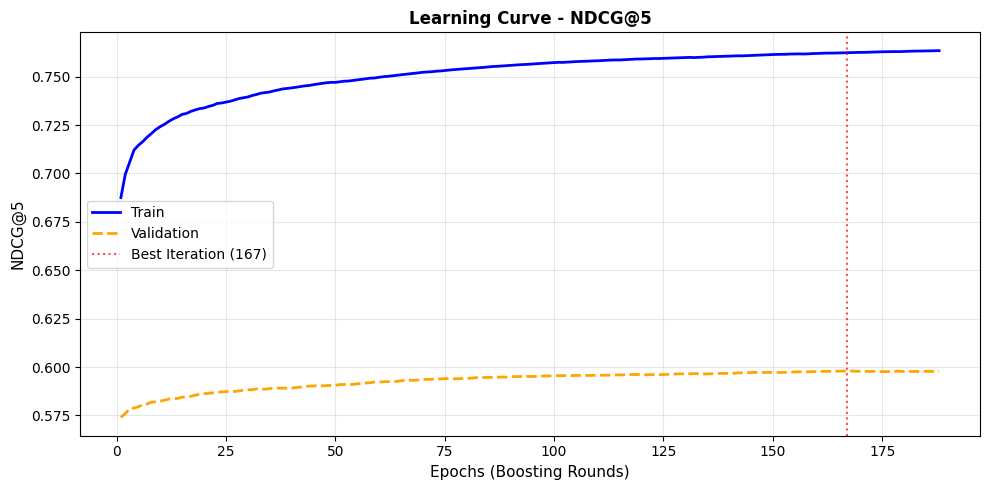


Thông tin Training:
  - Tổng số epochs đã chạy: 188
  - Best iteration (Điểm dừng tối ưu): 167
  - NDCG@5:
       Train (final): 0.763441
       Valid (final): 0.597830
       Valid (best):  0.597981


In [75]:
training_loop.plot_learning_curve(
    figsize=(10, 5)
)

### Huấn luyện lại Mô hình (Retrain)

Sau khi vòng lặp huấn luyện ban đầu kết thúc và tìm ra được số vòng lặp tối ưu (dựa trên cơ chế Early Stopping), hệ thống bước vào pha tối ưu hóa cuối cùng trước khi kiểm thử. 

Đoạn mã này thực hiện việc gộp tập Huấn luyện (Train) và tập Kiểm định (Validation) lại thành một tập dữ liệu lớn hơn. Mô hình XGBoost sau đó được khởi tạo lại và huấn luyện từ đầu trên tập dữ liệu gộp này với đúng số vòng lặp tối ưu đã tìm được. Chiến lược này giúp mô hình tận dụng được tối đa nguồn dữ liệu có sẵn để nâng cao khả năng tổng quát hóa.

In [76]:
# Retrain model trên train + valid với best parameters
xgb_ranker_retrained = training_loop.retrain_on_train_valid(
    df_train=df_train,
    df_valid=df_valid,
    sample_size=None  # None = sử dụng toàn bộ data
)


#################################################################
# RETRAIN TRÊN TRAIN + VALIDATION
#################################################################

Gộp dữ liệu:
  - Train gốc: 95,982 mẫu
  - Valid gốc: 20,670 mẫu
  - Train+Valid (Đã gộp): 116,652 mẫu

Sử dụng Best Parameters từ pha Training Loop trước đó:
  - n_estimators (Gắn cố định): 167 (Dựa trên best_iteration)
  - learning_rate: 0.1
  - max_depth: 6
  - objective: rank:ndcg

Xây dựng LTR Dataset cho tập Train+Valid...

Đang xây dựng tập dữ liệu LTR từ 116652 lượt truy vấn...
  - Tổng số mẫu dữ liệu (samples): 11,665,200
  - Số lượng truy vấn hợp lệ: 116,652
  - Số lượng mẫu mang nhãn Positive (y=1): 100,508 (0.86%)
  - Đã sắp xếp theo query_id: OK

Huấn luyện lại XGBRanker trên tập dữ liệu đã gộp...


Training XGBoost: 100%|████████████████████████████████████████| 167/167 [01:39<00:00,  1.68tree/s] 


  - Retrain hoàn tất!
  - Mô hình cuối cùng đã được huấn luyện với kiến thức từ 116,652 mẫu dữ liệu.


### So sánh trực quan

Sau khi hệ thống đã đi qua toàn bộ quy trình: Lọc thô (Content-Based) -> Huấn luyện với Early Stopping -> Huấn luyện lại (Retrain) trên toàn bộ dữ liệu, chúng ta sẽ lấy một truy vấn thực tế để kiểm chứng xem mô hình XGBRanker cuối cùng này đã cải thiện trải nghiệm tìm kiếm như thế nào so với bộ lọc văn bản ban đầu.

In [77]:
# Test với 1 query mẫu - So sánh trước và sau re-ranking (Dùng model đã Retrain)
if len(df_valid) > 0:
    # Lấy 1 sample từ tập Validation (hoặc có thể đổi thành tập Test nếu bạn muốn)
    sample_query = str(df_valid.iloc[2]['Comment'])
    sample_ground_truth = df_valid.iloc[2]['Name']
    
    print("\n" + "=" * 65)
    print("SO SÁNH TRƯỚC VÀ SAU RE-RANKING (MÔ HÌNH ĐÃ RETRAIN)")
    print("=" * 65)
    print(f"\nQuery: {sample_query[:200]}...")
    print(f"Ground Truth: {sample_ground_truth}")
    
    # TRƯỚC RE-RANKING (CBF only)
    # Đối tượng cbf vẫn giữ nguyên từ Bước 1
    cbf_candidates = cbf.get_candidates(sample_query, top_k=100)
    print(f"\nTRƯỚC (Content-Based) - Top 10 hiển thị:")
    display(cbf_candidates[['Name', 'Category', 'Cosine_Similarity_Score']].head(10))
    
    # Kiểm tra vị trí Ground Truth TRƯỚC re-ranking
    cbf_names = cbf_candidates['Name'].tolist()
    if sample_ground_truth in cbf_names:
        cbf_rank = cbf_names.index(sample_ground_truth) + 1
        print(f"-> Vị trí Ground Truth TRƯỚC re-ranking: #{cbf_rank}")
    else:
        cbf_rank = None
        print(f"-> Ground Truth KHÔNG nằm trong Top 100 TRƯỚC re-ranking.")
    
    # SAU RE-RANKING 
    # SỰ THAY ĐỔI QUAN TRỌNG: Gọi hàm rerank từ biến xgb_ranker_retrained
    xgb_candidates = xgb_ranker_retrained.rerank(sample_query, top_k=100)
    
    print(f"\nSAU (XGBRanker Retrained) - Top 10 hiển thị:")
    display(xgb_candidates[['Name', 'Category', 'Cosine_Similarity_Score', 'Relevance_Score']].head(10))
    
    # Kiểm tra vị trí Ground Truth SAU re-ranking
    xgb_names = xgb_candidates['Name'].tolist()
    if sample_ground_truth in xgb_names:
        xgb_rank = xgb_names.index(sample_ground_truth) + 1
        print(f"-> Vị trí Ground Truth SAU re-ranking: #{xgb_rank}")
    else:
        xgb_rank = None
        print(f"-> Ground Truth KHÔNG nằm trong Top 100 SAU re-ranking.")
        
    # TÓM TẮT SỰ CẢI THIỆN
    print("\nKẾT LUẬN:")
    if cbf_rank is not None and xgb_rank is not None:
        if xgb_rank < cbf_rank:
            print(f"Mô hình XGBRanker Tối ưu đã đẩy Ground Truth lên {cbf_rank - xgb_rank} bậc (Từ #{cbf_rank} -> #{xgb_rank}).")
        elif xgb_rank == cbf_rank:
            print(f"Vị trí Ground Truth không thay đổi (Giữ nguyên hạng #{xgb_rank}).")
        else:
            print(f"Mô hình XGBRanker Tối ưu làm giảm thứ hạng Ground Truth đi {xgb_rank - cbf_rank} bậc (Từ #{cbf_rank} -> #{xgb_rank}).")


SO SÁNH TRƯỚC VÀ SAU RE-RANKING (MÔ HÌNH ĐÃ RETRAIN)

Query: Không gian yên tĩnh, cảnh đẹp, cẩn thận với bầy khỉ...chúng giật đồ rất nhanh, chớp mắt......
Ground Truth: "Ngã 3 Sống Ảo" Lâm Viên - Đồng Đình, Rừng Sác

TRƯỚC (Content-Based) - Top 10 hiển thị:


,Name,Category,Cosine_Similarity_Score
0,Thư Viện Vĩnh Nghiêm Hồ Chí Minh,Attraction,0.247638
1,Bảo tàng Rừng Sác,Attraction,0.225902
2,Chiến khu Rừng Sác,Attraction,0.209517
3,Gà Rán KFC - Tân Kỳ Tân Quý,Dining,0.196734
4,Starbucks Coffee - Happy Residence,Dining,0.196721
5,Khu căn cứ Vàm Sát Đảo Khỉ,Attraction,0.195037
6,Chewy Chewy - Cafe & Bánh - Điện Biên Phủ,Dining,0.191634
7,Du lịch Rừng Sác - Cần Giờ,Attraction,0.188281
8,HUTECH UNIVERSITY LIBRARY,Attraction,0.183247
9,Công viên dưới chân cầu Nguyễn Văn Cừ,Attraction,0.166175


-> Vị trí Ground Truth TRƯỚC re-ranking: #12

SAU (XGBRanker Retrained) - Top 10 hiển thị:


,Name,Category,Cosine_Similarity_Score,Relevance_Score
0,Bảo tàng Rừng Sác,Attraction,0.225902,-0.114349
1,Chiến khu Rừng Sác,Attraction,0.209517,-0.939266
2,Khu căn cứ Vàm Sát Đảo Khỉ,Attraction,0.195037,-1.452398
3,Du lịch Rừng Sác - Cần Giờ,Attraction,0.188281,-1.706009
4,Khu Du Lịch Sinh thái Vàm Sát,Attraction,0.164161,-2.753132
5,"""Ngã 3 Sống Ảo"" Lâm Viên - Đồng Đình, Rừng Sác",Attraction,0.153100,-3.210790
6,Chùa Pháp Bửu,Attraction,0.149913,-3.442550
7,KDL Sinh Thái Vàm Sát Cần GIờ,Attraction,0.143639,-3.602501
8,Chùa Huyền Trang (Chùa Lá),Attraction,0.146330,-3.639948
9,Công Viên Sala,Attraction,0.112976,-3.672252


-> Vị trí Ground Truth SAU re-ranking: #6

KẾT LUẬN:
Mô hình XGBRanker Tối ưu đã đẩy Ground Truth lên 6 bậc (Từ #12 -> #6).


## **6. Đánh giá Hiệu năng Mô hình (Evaluation)**

Sau khi mô hình đã được huấn luyện, bước tiếp theo là đánh giá khả năng tổng quát hóa của nó trên tập dữ liệu Kiểm tra (Test Set) — tập dữ liệu được "cất giấu" từ đầu mà mô hình chưa từng nhìn thấy.

### 6.1. Các Độ đo Đánh giá (Evaluation Metrics)
Hệ thống sử dụng hai chỉ số phản ánh sát nhất với trải nghiệm tìm kiếm thực tế của người dùng:
* **Top-K Accuracy (Độ chính xác Top K / Hit Rate @ K):** Tính toán tỷ lệ phần trăm các truy vấn mà hệ thống gợi ý trúng "địa điểm thực tế" (Ground Truth) trong $K$ kết quả đầu tiên. 
* **Macro F1 @ K:** Điểm F1 trung bình trên tất cả các truy vấn. F1 đánh giá sự cân bằng giữa Precision (Độ chính xác) và Recall (Độ phủ). Vì mỗi lượt tìm kiếm chỉ có đúng 1 Ground Truth, Macro F1 giúp kiểm chứng xem hệ thống có đang gợi ý chính xác mà không bị "loãng" danh sách kết quả hay không.

### 6.2. Đánh giá Mô hình Baseline (Chỉ dùng CBF)
Đầu tiên, chúng ta đo lường hiệu năng của bộ lọc thô (Content-Based Filtering) để làm cột mốc (baseline) so sánh.

In [ ]:
print("=" * 60)
print("ĐÁNH GIÁ MÔ HÌNH BASELINE (CHỈ DÙNG CBF)")
print("=" * 60)

# Tự động tính điểm Top-5 Acc và Macro F1 cho CBF trên tập Test
cbf_hits = 0
cbf_f1_scores = []
queries = df_test['Comment'].astype(str).tolist()
ground_truths = df_test['Name'].tolist()

# Lấy top 5 dự đoán từ CBF
cbf_candidates_list = training_loop.cbf.get_candidates_batch(queries, top_k=5)

for gt, cands in zip(ground_truths, cbf_candidates_list):
    top5 = cands['Name'].tolist()
    if gt in top5:
        cbf_hits += 1
        cbf_f1_scores.append(2 / (5 + 1)) # F1 = 2 / (K + 1)
    else:
        cbf_f1_scores.append(0.0)

cbf_top5_acc = (cbf_hits / len(df_test)) * 100
cbf_macro_f1 = sum(cbf_f1_scores) / len(df_test)

print(f"  -> Top-5 Accuracy: {cbf_top5_acc:.2f}%")
print(f"  -> Macro F1 @ 5  : {cbf_macro_f1:.4f}")

ĐÁNH GIÁ MÔ HÌNH BASELINE (CHỈ DÙNG CBF)
  -> Top-5 Accuracy: 22.27%
  -> Macro F1 @ 5  : 0.0742


### 6.3. Đánh giá Mô hình Hybrid (CBF + XGBoost)
Tiếp theo, đánh giá hệ thống gợi ý hoàn chỉnh sau khi các ứng viên đã được chấm điểm và xếp hạng lại (Re-ranking) bởi thuật toán XGBoost.

In [97]:
print("=" * 50)
print("ĐÁNH GIÁ MÔ HÌNH HYBRID")
print("=" * 50)

# Đánh giá trên tập Test
test_hit_rate = training_loop.get_top5_accuracy(df_test, sample_size=None)

ĐÁNH GIÁ MÔ HÌNH HYBRID
  - Top-5 Accuracy: 25.99% (5373/20670)
  - Macro F1 @ 5: 0.0866


### Đánh giá Toàn diện với nhiều Ngưỡng K (Comprehensive Evaluation)

Thay vì chỉ nhìn vào một chỉ số duy nhất (Top 5), đoạn mã này thực hiện việc đánh giá toàn diện mô hình trên nhiều ngưỡng $K$ khác nhau (1, 3, 5, 10). 

In [82]:
# Đánh giá toàn diện với nhiều ngưỡng K
print("ĐÁNH GIÁ TOÀN DIỆN TRÊN TEST SET")
print("-" * 45)

results = []
for k in [1, 3, 5, 10]:
    # Lấy Hit Rate và chi tiết (bao gồm cả Macro F1) từ Evaluator
    hit_rate, metrics = training_loop.evaluator.compute_hit_rate_at_k(
        df=df_test, k=k, sample_size=None, verbose=False
    )
    
    results.append({
        'K': k,
        'Top-K Accuracy (%)': round(hit_rate, 2),
        'Macro F1': round(metrics['macro_f1'], 4),
        'Hits': metrics['hits'],
        'Total': metrics['total']
    })
    print(f"  Top-{k} Accuracy: {hit_rate:.2f}% | Macro F1: {metrics['macro_f1']:.4f}")

display(pd.DataFrame(results))

ĐÁNH GIÁ TOÀN DIỆN TRÊN TEST SET
---------------------------------------------
  Top-1 Accuracy: 13.04% | Macro F1: 0.1304
  Top-3 Accuracy: 21.40% | Macro F1: 0.1070
  Top-5 Accuracy: 25.99% | Macro F1: 0.0866
  Top-10 Accuracy: 33.00% | Macro F1: 0.0600


,K,Top-K Accuracy (%),Macro F1,Hits,Total
0,1,13.04,0.1304,2696,20670
1,3,21.40,0.1070,4424,20670
2,5,25.99,0.0866,5373,20670
3,10,33.00,0.0600,6822,20670


### 6.2. Huấn luyện trên Toàn bộ Dữ liệu (Full Training)

Ở phần trước, chúng ta đã sử dụng tập Kiểm tra (Test Set) để đánh giá khách quan hiệu năng của mô hình. Giờ đây, khi đã xác nhận được kiến trúc và các siêu tham số (hyperparameters) là tối ưu, chúng ta không cần phải giữ lại bất kỳ tập dữ liệu nào nữa.

Mục tiêu của phần này là chuẩn bị một phiên bản mô hình **"sẵn sàng cho môi trường thực tế" (Production-Ready)**. 
Hệ thống sẽ tiến hành gộp tất cả các tập dữ liệu hiện có (Train + Validation + Test) thành một tập dữ liệu tổng duy nhất. Mô hình XGBRanker sau đó sẽ được huấn luyện lại (retrain) từ đầu trên tập dữ liệu khổng lồ này, sử dụng chính xác số vòng lặp tối ưu (`best_iteration`) đã tìm được từ quá trình Early Stopping trước đó. Việc này giúp mô hình tận dụng được 100% tri thức từ dữ liệu để đạt hiệu suất cao nhất có thể.

---

### Lớp Huấn luyện Toàn bộ (Full Pipeline Trainer)

Lớp `FullPipelineTrainer` tự động hóa quy trình chuẩn bị một mô hình sẵn sàng để triển khai:
1. **Gộp dữ liệu:** Nối tập Train, Valid và Test thành một khối duy nhất.
2. **Khởi tạo lại Bộ lọc:** Huấn luyện lại bộ lọc TF-IDF (Content-Based) trên toàn bộ dữ liệu để nó cập nhật được những từ vựng và địa điểm mới nhất từ tập Valid/Test.
3. **Huấn luyện Lõi XGBoost:** Huấn luyện trực tiếp thuật toán XGBRanker với số vòng lặp tối ưu mà không cần cơ chế dừng sớm (Early Stopping).
4. **Lưu trữ (Serialization):** Đóng gói toàn bộ các cấu phần (Bộ lọc văn bản, Bộ mã hóa đặc trưng, Mô hình lõi) thành các file nhị phân (`.pkl`) để có thể tải lên server phục vụ bước Suy luận (Inference).

In [83]:
class FullPipelineTrainer:
    """
    Class quản lý việc huấn luyện lại toàn bộ pipeline trên 100% dữ liệu (Full Data) 
    và lưu trữ các cấu phần (components) ra ổ cứng để phục vụ môi trường Production.
    """
    
    def __init__(self, checkpoint_dir: str = 'checkpoints'):
        """
        Khởi tạo đối tượng FullPipelineTrainer.
        
        Args:
            checkpoint_dir: Đường dẫn thư mục dùng để lưu trữ các file mô hình (checkpoint).
        """
        self.checkpoint_dir = Path(checkpoint_dir)
        # Tự động tạo thư mục nếu chưa tồn tại
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        
        # Các cấu phần (components) này sẽ được khởi tạo trong hàm train
        self.cbf = None
        self.dataset_builder = None
        self.xgb_model = None
        self.df_full = None
    
    def train(
        self,
        df_train: pd.DataFrame,
        df_valid: pd.DataFrame,
        df_test: pd.DataFrame,
        best_n_estimators: int,
        top_k: int = 100,
        learning_rate: float = 0.1,
        max_depth: int = 6,
        objective: str = 'rank:ndcg',
        sample_size: Optional[int] = None
    ) -> 'FullPipelineTrainer':
        """
        Tiến hành huấn luyện toàn bộ pipeline từ đầu đến cuối.
        """
        print("\n" + "#" * 65)
        print("# GIAI ĐOẠN 5: FULL TRAINING & LƯU MÔ HÌNH")
        print("#" * 65)
        
        # Bắt đầu đo thời gian huấn luyện
        full_train_start_time = time.time()
        
        # Bước 1: Gộp tất cả các tập dữ liệu để tối đa hóa lượng thông tin học được
        print("\nBước 1: Gộp df_train + df_valid + df_test thành df_full...")
        self.df_full = pd.concat([df_train, df_valid, df_test], ignore_index=True)
        print(f"  - Tổng số dòng dữ liệu df_full: {len(self.df_full):,}")
        
        # Lấy mẫu nếu hệ thống bị hạn chế tài nguyên bộ nhớ
        if sample_size and len(self.df_full) > sample_size:
            df_train_full = self.df_full.sample(n=sample_size, random_state=42)
            print(f"  - Đã lấy mẫu: {len(df_train_full):,} dòng để tiến hành train")
        else:
            df_train_full = self.df_full
        
        # Bước 2: Khởi tạo và huấn luyện lại Giai đoạn 1 (Content-Based Filtering)
        print(f"\nBước 2: Khởi tạo lại ContentBasedFilter (top_k={top_k})...")
        self.cbf = ContentBasedFilter(top_k=top_k)
        # Fit trên toàn bộ data để TF-IDF cập nhật toàn bộ từ vựng mới
        self.cbf.fit(self.df_full)  
        print(f"  - Số lượng hồ sơ địa điểm (items): {len(self.cbf.item_profiles):,}")
        
        # Bước 3: Khởi tạo và xây dựng bộ dữ liệu Tabular (Giai đoạn 2)
        print(f"\nBước 3: Xây dựng LTR Dataset từ dữ liệu đã gộp...")
        self.dataset_builder = LearningToRankDataset(cbf=self.cbf, top_k=top_k)
        # Bắt buộc fit_encoder=True để OneHotEncoder cập nhật tất cả Categories
        X_full, y_full, qid_full = self.dataset_builder.build_dataset(
            df_train_full, fit_encoder=True
        )
        
        # Bước 4: Khởi tạo và huấn luyện lõi XGBoost
        # Sử dụng chính xác tham số best_n_estimators đã tìm được từ tập Valid trước đó
        print(f"\nBước 4: Huấn luyện XGBRanker trên Full Data...")
        print(f"  - n_estimators (Gắn cố định từ best_iteration): {best_n_estimators}")
        print(f"  - learning_rate: {learning_rate}")
        print(f"  - max_depth: {max_depth}")
        print(f"  - objective: {objective}")
        print(f"  - early_stopping: ĐÃ TẮT (Vì đang huấn luyện trên toàn bộ dữ liệu)")
        
        progress_callback = TqdmXGBCallback(best_n_estimators)
        self.xgb_model = XGBRanker(
            n_estimators=best_n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            objective=objective,
            tree_method='hist',
            random_state=42,
            n_jobs=-1,
            callbacks=[progress_callback]
        )
        
        # Khớp dữ liệu trực tiếp mà không cần eval_set
        self.xgb_model.fit(
            X_full, y_full,
            qid=qid_full
        )
        
        # Kết thúc đo thời gian huấn luyện
        full_train_time = time.time() - full_train_start_time
        
        progress_callback.close()
        print(f"\n  - Huấn luyện Full Pipeline hoàn tất!")
        print(f"  - Thời gian huấn luyện (Full Training Time): {full_train_time:.2f} giây ({full_train_time/60:.2f} phút)")
        
        return self
    
    def save(self, prefix: str = 'vietnam_tourism') -> dict:
        """
        Chuyển đổi (Serialize) và lưu trữ các thành phần của pipeline xuống ổ cứng.
        
        Returns:
            Một dictionary chứa thông tin đường dẫn của các file đã lưu.
        """
        print(f"\nBước 5: Lưu Checkpoint vào thư mục '{self.checkpoint_dir}'...")
        
        saved_files = {}
        
        # 1. Lưu ContentBasedFilter (chứa ma trận TF-IDF và thông tin địa điểm)
        cbf_path = self.checkpoint_dir / f'{prefix}_cbf.pkl'
        joblib.dump(self.cbf, cbf_path)
        saved_files['cbf'] = str(cbf_path)
        print(f"  - Đã lưu ContentBasedFilter: {cbf_path}")
        
        # 2. Lưu LTR Dataset Builder (chứa bộ mã hóa Category OneHotEncoder)
        # MẸO TỐI ƯU: Tạm thời ngắt kết nối biến self.cbf bên trong dataset_builder 
        # trước khi lưu để tránh việc thư viện joblib sao chép thừa (lưu trùng đối tượng cbf 2 lần)
        # làm phình to kích thước file checkpoint.
        encoder_path = self.checkpoint_dir / f'{prefix}_encoder.pkl'
        original_cbf_ref = self.dataset_builder.cbf
        try:
            self.dataset_builder.cbf = None
            joblib.dump(self.dataset_builder, encoder_path)
        finally:
            # Phục hồi lại kết nối sau khi lưu xong
            self.dataset_builder.cbf = original_cbf_ref
            
        saved_files['encoder'] = str(encoder_path)
        print(f"  - Đã lưu Feature Encoder: {encoder_path}")
        
        # 3. Lưu mô hình lõi XGBRanker
        # Cần gỡ bỏ `callbacks` (tqdm instance) trước khi lưu mô hình vì obj này gây lỗi khi pickle
        model_path = self.checkpoint_dir / f'{prefix}_xgbranker.pkl'
        
        # Remove callbacks before path dump
        original_callbacks = getattr(self.xgb_model, 'callbacks', None)
        if hasattr(self.xgb_model, 'callbacks'):
            self.xgb_model.callbacks = None
        
        try:
            joblib.dump(self.xgb_model, model_path)
        finally:
            if hasattr(self.xgb_model, 'callbacks'):
                self.xgb_model.callbacks = original_callbacks

        saved_files['xgbranker'] = str(model_path)
        print(f"  - Đã lưu XGBRanker: {model_path}")
        
        # 4. Lưu Metadata (thông tin cấu hình để dễ dàng kiểm tra sau này)
        metadata = {
            'n_items': len(self.cbf.item_profiles),
            'n_estimators': self.xgb_model.n_estimators,
            'top_k': self.dataset_builder.top_k,
            'files': saved_files
        }
        metadata_path = self.checkpoint_dir / f'{prefix}_metadata.pkl'
        joblib.dump(metadata, metadata_path)
        saved_files['metadata'] = str(metadata_path)
        print(f"  - Đã lưu Metadata: {metadata_path}")
        
        print(f"\n  - Hoàn tất! Đã lưu {len(saved_files)} files thành công.")
        
        return saved_files

### Thực thi huấn luyện trenet toàn bộ dữ liệu (Full Training)

Đoạn mã này chính thức kích hoạt quá trình "Full Training" bằng cách gọi lớp `FullPipelineTrainer`.

Điểm mấu chốt ở đây là việc trích xuất số lượng cây quyết định tối ưu (`best_n_estimators`) từ quá trình huấn luyện có sử dụng Early Stopping ở Giai đoạn 3.

Sau khi huấn luyện xong trên toàn bộ dữ liệu (Train + Valid + Test), hệ thống sẽ lập tức xuất (export) toàn bộ các cấu phần của mô hình ra thư mục `checkpoints`, sẵn sàng để nạp vào môi trường thực tế (Production).

In [100]:
best_n_estimators = training_loop.best_iteration
print(f"Số lượng cây tối ưu (n_estimators): {best_n_estimators}")

# Khởi tạo Full Pipeline Trainer
full_trainer = FullPipelineTrainer(checkpoint_dir='checkpoints')

# Huấn luyện trên toàn bộ dữ liệu
full_trainer.train(
    df_train=df_train,
    df_valid=df_valid,
    df_test=df_test,
    best_n_estimators=best_n_estimators,
    top_k=100,
    learning_rate=0.1,
    max_depth=6,
    objective='rank:ndcg',
    sample_size=None
)

Số lượng cây tối ưu (n_estimators): 167

#################################################################
# GIAI ĐOẠN 5: FULL TRAINING & LƯU MÔ HÌNH
#################################################################

Bước 1: Gộp df_train + df_valid + df_test thành df_full...
  - Tổng số dòng dữ liệu df_full: 137,322

Bước 2: Khởi tạo lại ContentBasedFilter (top_k=100)...

############################################################
# GIAI ĐOẠN 1: CONTENT-BASED FILTERING
############################################################

Bước 1: Xây dựng Item Profiles từ tập train...
  - Đã xây dựng 5987 Item Profiles

Bước 2: Fit TF-IDF Vectorizer...
  - Vocabulary size: 5000
  - Item vectors shape: (5987, 5000)
  - Số lượng hồ sơ địa điểm (items): 5,987

Bước 3: Xây dựng LTR Dataset từ dữ liệu đã gộp...

Đang xây dựng tập dữ liệu LTR từ 137322 lượt truy vấn...
  - Tổng số mẫu dữ liệu (samples): 13,732,200
  - Số lượng truy vấn hợp lệ: 137,322
  - Số lượng mẫu mang nhãn Positive (y=1): 122,4

Training XGBoost: 100%|████████████████████████████████████████| 167/167 [05:02<00:00,  1.81s/tree] 


  - Huấn luyện Full Pipeline hoàn tất!
  - Thời gian huấn luyện (Full Training Time): 603.66 giây (10.06 phút)


## **7. Lưu checkpoint**

Sau khi hoàn tất quá trình huấn luyện trên toàn bộ dữ liệu, việc lưu trữ là cần thiết để hệ thống có thể hoạt động độc lập mà không cần huấn luyện lại từ đầu.

Thực hiện lưu trữ tại `./checkpoints/`, bao gồm 4 file `.pkl`:
- **CBF:** Bộ lọc TF-IDF và ma trận vector hóa địa điểm
- **Encoder:** Bộ mã hóa One-Hot cho Category
- **XGBRanker:** Mô hình học xếp hạng
- **Metadata:** Thông tin cấu hình hệ thống

In [85]:
# Lưu checkpoint
saved_files = full_trainer.save(prefix='vietnam_tourism')
print(f"\nĐã lưu {len(saved_files)} files vào thư mục checkpoints/")


Bước 5: Lưu Checkpoint vào thư mục 'checkpoints'...
  - Đã lưu ContentBasedFilter: checkpoints\vietnam_tourism_cbf.pkl
  - Đã lưu Feature Encoder: checkpoints\vietnam_tourism_encoder.pkl
  - Đã lưu XGBRanker: checkpoints\vietnam_tourism_xgbranker.pkl
  - Đã lưu Metadata: checkpoints\vietnam_tourism_metadata.pkl

  - Hoàn tất! Đã lưu 4 files thành công.

Đã lưu 4 files vào thư mục checkpoints/


## **8. Suy luận và hậu xử lý cho bài toán gợi ý**

### 8.1. Giai đoạn Suy luận (Inference Pipeline)

Đây là bước cuối cùng, nơi toàn bộ quy trình học máy và xử lý dữ liệu được đóng gói thành một hệ thống hoàn chỉnh (`VietnamTourismRecommender`), đạt tiêu chuẩn để triển khai trên môi trường thực tế (Production). 

Hệ thống không chỉ phụ thuộc vào điểm số từ model mà còn kết hợp chặt chẽ với các quy tắc nghiệp vụ (Business Rules) để giải quyết trọn vẹn bài toán lập kế hoạch chuyến đi của người dùng. Quy trình hoạt động được chia thành 5 bước cốt lõi:

#### 8.1.1. Khởi tạo và Tải Mô hình (Model Initialization)
Hệ thống tự động nạp các cấu phần đã lưu từ Bước 5 (bao gồm Bộ lọc văn bản TF-IDF, Bộ tiền xử lý đặc trưng, Lõi XGBRanker và Metadata) vào bộ nhớ tĩnh để sẵn sàng xử lý các truy vấn với độ trễ thấp nhất.

#### 8.1.2. Lọc Cứng & Cơ chế Nới lỏng Thông minh (Hard Filtering & Smart Fallback)
Hệ thống tiếp nhận yêu cầu về Khu vực (hỗ trợ nhiều quận cùng lúc) và Ngân sách từ người dùng.
- **Lọc cứng:** Sử dụng biểu thức chính quy nâng cao (Regex Negative Lookahead) để đối chiếu chính xác ranh giới hành chính trên cột Địa chỉ.
- **Nới lỏng thông minh:** Để tránh việc bộ lọc khắt khe loại bỏ toàn bộ ứng viên, hệ thống thiết lập cơ sở trích xuất thô lên gấp 5 lần (Buffer Zone). Đặc biệt, nếu danh sách sau khi lọc rỗng HOẶC không chứa bất kỳ Khách sạn nào, cơ chế Fallback sẽ được kích hoạt tuần tự: Tăng 20% ngân sách -> Bỏ giới hạn ngân sách -> Bỏ giới hạn khu vực. Cơ chế này đảm bảo hệ thống luôn có khả năng cung cấp giải pháp dự phòng tốt nhất.

#### 8.1.3. Xếp hạng (Ranking Stage)
Các ứng viên vượt qua vòng lọc cứng sẽ được chuyển đổi thành ma trận đặc trưng số học. Mô hình XGBRanker tiến hành chấm điểm Độ phù hợp (Relevance Score) cho từng ứng viên dựa trên dữ liệu đánh giá tổng hợp đa chiều.

#### 8.1.4. Tối ưu Khoảng cách Hành chính (Location Matching Strategy)
Để tạo ra một lịch trình di chuyển khả thi và hợp lý về mặt không gian (Bao gồm 1 Khách sạn, 2 Ẩm thực, 3 Tham quan), hệ thống áp dụng chiến lược lấy nơi lưu trú làm trung tâm:
- Trích xuất tự động Quận/Huyện của Khách sạn có điểm số cao nhất.
- Tiến hành rà soát các địa điểm Ẩm thực và Tham quan. Các dịch vụ nằm CÙNG khu vực hành chính với khách sạn sẽ được ưu tiên giữ nguyên điểm. Các dịch vụ nằm KHÁC khu vực sẽ bị áp dụng hình phạt khoảng cách (Distance Penalty - giảm 20% điểm số) trước khi tiến hành chọn lọc chung cuộc.

#### 8.1.5. Tính minh bạch và Trình bày (Explainability & Presentation)
Cấu trúc đầu ra được chuẩn hóa để hiển thị đầy đủ các thông tin thiết yếu như Giờ hoạt động, Khung giá và Liên kết tham khảo. Đáng chú ý, hệ thống tích hợp thêm cơ chế Giải thích (Explainable) thông qua trường Lý do (Reason), giúp người dùng hiểu rõ căn cứ thuật toán đằng sau mỗi gợi ý trong lịch trình.

---

In [101]:
class VietnamTourismRecommender:
    """
    Class chính cho Hệ thống Tư vấn Du lịch Việt Nam.
    
    Phục vụ giai đoạn Suy luận (Inference) trên môi trường thực tế.
    Tích hợp bộ lọc cứng, cơ chế nới lỏng (fallback) và tối ưu khoảng cách hành chính.
    """
    
    def __init__(self, checkpoint_dir: str = 'checkpoints', prefix: str = 'vietnam_tourism'):
        """
        Khởi tạo hệ thống và nạp các thành phần từ file checkpoint.
        """
        self.checkpoint_dir = Path(checkpoint_dir)
        self.prefix = prefix
        self._load_components()

    def _load_components(self):
        """Hàm nội bộ để nạp các file .pkl vào bộ nhớ."""
        print("\nĐang nạp mô hình từ checkpoint...")
        try:
            cbf_path = self.checkpoint_dir / f'{self.prefix}_cbf.pkl'
            self.cbf = joblib.load(cbf_path)

            encoder_path = self.checkpoint_dir / f'{self.prefix}_encoder.pkl'
            self.dataset_builder = joblib.load(encoder_path)
            # Khôi phục liên kết bộ lọc văn bản
            self.dataset_builder.cbf = self.cbf

            model_path = self.checkpoint_dir / f'{self.prefix}_xgbranker.pkl'
            self.xgb_model = joblib.load(model_path)

            metadata_path = self.checkpoint_dir / f'{self.prefix}_metadata.pkl'
            self.metadata = joblib.load(metadata_path)
            
            print(f"Tải hệ thống thành công! (Sẵn sàng phục vụ {self.metadata['n_items']:,} địa điểm)")
        except Exception as e:
            print(f"Lỗi khi nạp mô hình: {str(e)}")

    def _extract_district(self, address: str) -> str:
        """
        Trích xuất tên Quận/Huyện/Thành phố từ chuỗi địa chỉ để phục vụ đối chiếu vị trí.
        """
        if not isinstance(address, str):
            return "Unknown"
        
        parts = address.split(',')
        for part in parts:
            part = part.strip()
            if any(keyword in part for keyword in ["Quận", "Huyện", "Thị xã", "Thành phố"]):
                return part.strip()
        return "Unknown"

    def _has_hotel(self, df: pd.DataFrame) -> bool:
        """
        Kiểm tra xem trong danh sách có tồn tại ít nhất 1 khách sạn không.
        Phục vụ cho cơ chế Fallback thông minh.
        """
        if df.empty: 
            return False
        return df['Category'].str.contains('hotel', case=False, na=False).any()

    def _apply_hard_filter(self, df: pd.DataFrame, districts: Optional[List[str]], max_price: Optional[float]) -> pd.DataFrame:
        """
        Lọc cứng danh sách ứng viên theo Quận và Ngân sách.
        Sử dụng Negative Lookahead để tránh lỗi Quận 1 khớp với Quận 10, Quận 11.
        """
        temp_df = df.copy()
        
        # Lọc theo danh sách Quận (Regex OR kết hợp Negative Lookahead)
        if districts:
            pattern = '|'.join([rf"{d}(?![0-9])" for d in districts])
            temp_df = temp_df[temp_df['Address'].str.contains(pattern, case=False, na=False)]
        
        # Lọc theo Giá tối đa
        if max_price is not None:
            prices = pd.to_numeric(temp_df['Price_min'], errors='coerce').fillna(0)
            temp_df = temp_df[prices <= max_price]
            
        return temp_df

    def recommend(
        self, 
        user_query: str, 
        districts: Optional[List[str]] = None, 
        max_price: Optional[float] = None,
        verbose: bool = True
    ) -> Dict[str, Any]:
        """
        Tiếp nhận truy vấn và đưa ra danh sách gợi ý tốt nhất.
        """
        if verbose:
            print("\n" + "=" * 70)
            print("VIETNAM TOURISM RECOMMENDER - QUÁ TRÌNH SUY LUẬN")
            print("=" * 70)
            display_query = user_query[:100] + "..." if len(user_query) > 100 else user_query
            print(f"Truy vấn: {display_query}")
            print(f"Khu vực yêu cầu: {districts if districts else 'Toàn quốc'}")
            print(f"Ngân sách tối đa: {max_price:,} VNĐ" if max_price else "Ngân sách: Không giới hạn")

        # Bước 1: Trích xuất ứng viên thô (Lấy gấp 5 lần để tạo vùng đệm cho bộ lọc)
        base_top_k = self.metadata.get('top_k', 100)
        fetch_k = base_top_k * 5
        candidates = self.cbf.get_candidates(user_query, top_k=fetch_k)
        
        if candidates.empty:
            return self._empty_response()

        # Bước 2: Lọc cứng và Cơ chế Nới lỏng (Fallback thông minh)
        current_max_price = max_price
        current_districts = districts
        warning_msg = "Thỏa mãn toàn bộ tiêu chí tìm kiếm."
        
        filtered_df = self._apply_hard_filter(candidates, current_districts, current_max_price)
        
        # Fallback 1: Tăng ngân sách 20%
        if (filtered_df.empty or not self._has_hotel(filtered_df)) and max_price is not None:
            warning_msg = "Không tìm thấy kết quả phù hợp. Hệ thống đã nới lỏng ngân sách thêm 20%."
            filtered_df = self._apply_hard_filter(candidates, current_districts, max_price * 1.2)
            
            # Fallback 2: Bỏ giới hạn ngân sách
            if filtered_df.empty or not self._has_hotel(filtered_df):
                warning_msg = "Ngân sách quá thấp. Hệ thống đã loại bỏ tiêu chí ngân sách để tìm gợi ý."
                filtered_df = self._apply_hard_filter(candidates, current_districts, None)
                
        # Fallback 3: Bỏ giới hạn khu vực
        if (filtered_df.empty or not self._has_hotel(filtered_df)) and districts:
            warning_msg = "Khu vực này không có đủ dịch vụ. Hệ thống đã mở rộng tìm kiếm toàn quốc."
            filtered_df = candidates.copy()

        if verbose:
            print(f"\nTrạng thái lọc: {warning_msg}")
            print(f"Số lượng ứng viên đưa vào chấm điểm: {min(len(filtered_df), base_top_k)}")

        # Giới hạn lại số lượng đưa vào XGBoost
        if len(filtered_df) > base_top_k:
            filtered_df = filtered_df.head(base_top_k)
            
        # Bước 3: XGBRanker tính điểm phù hợp
        features = self.dataset_builder._prepare_features(filtered_df)
        relevance_scores = self.xgb_model.predict(features)
        
        filtered_df = filtered_df.copy()
        filtered_df['Relevance_Score'] = relevance_scores
        filtered_df = filtered_df.sort_values('Relevance_Score', ascending=False).reset_index(drop=True)
        
        # Bước 4: Áp dụng Logic Nghiệp vụ & Vị trí
        return self._apply_business_logic(filtered_df, warning_msg, verbose)

    def _apply_business_logic(self, df: pd.DataFrame, warning_msg: str, verbose: bool) -> Dict[str, Any]:
        """
        Quyết định cấu trúc đầu ra (1 Hotel, 2 Dining, 3 Attraction) và phạt điểm khoảng cách.
        """
        results = {'hotels': [], 'dining': [], 'attractions': []}
        
        # Tìm Khách sạn có điểm cao nhất làm tâm điểm
        hotel_df = df[df['Category'].str.contains('hotel', case=False, na=False)]
        if hotel_df.empty:
            return self._empty_response(warning_msg="Không tìm thấy khách sạn nào trong dữ liệu.")
            
        best_hotel = hotel_df.iloc[0].to_dict()
        hotel_district = self._extract_district(best_hotel.get('Address', ''))
        best_hotel['Reason'] = f"Lựa chọn lưu trú phù hợp nhất (Độ phù hợp: {best_hotel['Relevance_Score']:.2f})."
        results['hotels'].append(best_hotel)

        # Xử lý phần còn lại (Ẩm thực và Tham quan)
        other_df = df[~df['Category'].str.contains('hotel', case=False, na=False)].copy()
        
        def calculate_adjusted_score(row):
            dist = self._extract_district(row.get('Address', ''))
            score = row['Relevance_Score']
            is_same_district = (dist == hotel_district and hotel_district != "Unknown")
            
            # Phạt 20% điểm nếu không nằm cùng khu vực với khách sạn
            final_score = score if is_same_district else score * 0.8
            
            reason = "Cùng khu vực với khách sạn, rất thuận tiện di chuyển " if is_same_district else "Nằm khác khu vực với khách sạn "
            reason += f"(Độ phù hợp sau điều chỉnh: {final_score:.2f})."
            return final_score, reason

        if not other_df.empty:
            other_df[['Final_Score', 'Reason']] = other_df.apply(
                lambda r: pd.Series(calculate_adjusted_score(r)), axis=1
            )
            other_df = other_df.sort_values('Final_Score', ascending=False)

            dining = other_df[other_df['Category'].str.contains('dining', case=False, na=False)].head(2)
            attractions = other_df[other_df['Category'].str.contains('attraction', case=False, na=False)].head(3)
            
            results['dining'] = dining.to_dict('records')
            results['attractions'] = attractions.to_dict('records')

        results['warning'] = warning_msg
        return results

    def _empty_response(self, warning_msg: str = "Không tìm thấy kết quả.") -> Dict[str, Any]:
        """Trả về cấu trúc rỗng khi truy vấn thất bại."""
        return {'hotels': [], 'dining': [], 'attractions': [], 'warning': warning_msg}

    def pretty_print(self, result: Dict[str, Any]):
        """In kết quả ra màn hình."""
        print("\n" + "=" * 70)
        print("KẾT QUẢ GỢI Ý LỊCH TRÌNH DU LỊCH")
        print("=" * 70)
        print(f"Hệ thống thông báo: {result.get('warning')}")
        
        sections = [
            ("KHÁCH SẠN LƯU TRÚ (Gợi ý 1 địa điểm)", 'hotels'),
            ("ẨM THỰC ĐỊA PHƯƠNG (Gợi ý 2 địa điểm)", 'dining'),
            ("ĐIỂM THAM QUAN (Gợi ý 3 địa điểm)", 'attractions')
        ]
        
        for title, key in sections:
            print(f"\n[ {title} ]")
            print("-" * 50)
            if not result[key]:
                print("  Không có dữ liệu phù hợp.")
                continue
            
            for i, item in enumerate(result[key], 1):
                name = item.get('Name', 'N/A')
                address = item.get('Address', 'N/A')
                start_time = item.get('Start', 'N/A')
                end_time = item.get('End', 'N/A')
                price_min = item.get('Price_min', 0)
                price_max = item.get('Price_max', 0)
                score = item.get('Score', 'N/A')
                reason = item.get('Reason', '')
                url = item.get('Url', 'Không có liên kết')
                
                print(f"  {i}. {name}")
                print(f"     - Địa chỉ: {address}")
                print(f"     - Giờ hoạt động: {start_time} - {end_time}")
                
                # Format giá tiền an toàn
                try:
                    price_str = f"{float(price_min):,} - {float(price_max):,} VNĐ"
                except (ValueError, TypeError):
                    price_str = f"{price_min} - {price_max} VNĐ"
                    
                print(f"     - Mức giá: {price_str} | Điểm đánh giá: {score}/10")
                print(f"     - Lý do gợi ý: {reason}")
                print(f"     - Liên kết: {url}")

        print("\n" + "=" * 70)

#### Thực thi và Kiểm thử Hệ thống (Inference Testing)

Sau khi định nghĩa hoàn chỉnh class `VietnamTourismRecommender`, bước cuối cùng là khởi tạo hệ thống từ các file checkpoint đã lưu và tiến hành chạy kiểm thử (Testing) trên các truy vấn giả lập.

Quá trình kiểm thử được thiết kế với hai kịch bản nhằm đánh giá khả năng xử lý các tình huống thực tế của bộ lọc nghiệp vụ:

* **Kịch bản 1 - Xác thực Bộ lọc Ranh giới Hành chính:** Mô phỏng một truy vấn tiêu chuẩn yêu cầu tìm kiếm đồng thời trong hai khu vực (Quận 1 và Quận 3). Mục đích nhằm kiểm chứng độ chính xác của biểu thức Regex, đảm bảo hệ thống chặn đứng lỗi nhận diện (ví dụ: không lấy nhầm dữ liệu của Quận 10 hay Quận 11).
* **Kịch bản 2 - Xác thực Cơ chế Nới lỏng (Smart Fallback):** Mô phỏng một yêu cầu bất khả thi về mặt thực tế (tìm khách sạn 5 sao tại trung tâm Quận 1 với ngân sách siêu rẻ 100,000 VNĐ). Mục đích nhằm ép hệ thống rơi vào trạng thái cạn kiệt ứng viên, qua đó kiểm chứng khả năng tự động nhận thức và xé rào giới hạn ngân sách để cung cấp giải pháp lưu trú thay thế tốt nhất cho người dùng.

In [87]:
# Khởi tạo hệ thống
recommender = VietnamTourismRecommender(checkpoint_dir='checkpoints')

# Kịch bản 1: Tìm kiếm tiêu chuẩn với bộ lọc Đa Quận (Kiểm tra lỗi Regex)
query_1 = "Tôi muốn tìm một nơi có không gian yên tĩnh, lãng mạn, đồ ăn ngon để đi cùng gia đình."
ket_qua_1 = recommender.recommend(
    user_query=query_1, 
    districts=['Quận 1', 'Quận 3'], 
    max_price=500000, 
    verbose=True
)
recommender.pretty_print(ket_qua_1)

# Kịch bản 2: Tìm kiếm với yêu cầu quá gắt gao (Kiểm tra tính năng Fallback thông minh)
query_2 = "Khách sạn 5 sao chuẩn quốc tế, sang trọng."
ket_qua_2 = recommender.recommend(
    user_query=query_2, 
    districts=['Quận 1'], 
    max_price=100000, 
    verbose=True
)
recommender.pretty_print(ket_qua_2)


Đang nạp mô hình từ checkpoint...
Tải hệ thống thành công! (Sẵn sàng phục vụ 5,987 địa điểm)

VIETNAM TOURISM RECOMMENDER - QUÁ TRÌNH SUY LUẬN
Truy vấn: Tôi muốn tìm một nơi có không gian yên tĩnh, lãng mạn, đồ ăn ngon để đi cùng gia đình.
Khu vực yêu cầu: ['Quận 1', 'Quận 3']
Ngân sách tối đa: 500,000 VNĐ

Trạng thái lọc: Thỏa mãn toàn bộ tiêu chí tìm kiếm.
Số lượng ứng viên đưa vào chấm điểm: 100

KẾT QUẢ GỢI Ý LỊCH TRÌNH DU LỊCH
Hệ thống thông báo: Thỏa mãn toàn bộ tiêu chí tìm kiếm.

[ KHÁCH SẠN LƯU TRÚ (Gợi ý 1 địa điểm) ]
--------------------------------------------------
  1. Ahu Hotel & Apartment
     - Địa chỉ: 373/49 Phạm Ngũ Lão, Quận 1
     - Giờ hoạt động: 0:00 - 23:59
     - Mức giá: 432,000.0 - 432,000.0 VNĐ | Điểm đánh giá: 3.9/10
     - Lý do gợi ý: Lựa chọn lưu trú phù hợp nhất (Độ phù hợp: -2.59).
     - Liên kết: https://www.booking.com/hotel/vn/central-perk-saigon.vi.html

[ ẨM THỰC ĐỊA PHƯƠNG (Gợi ý 2 địa điểm) ]
--------------------------------------------------

## **9. Đánh giá độ phức tạp và chi phí của mô hình**

Phần này tổng hợp lại các chi phí về mặt lưu trữ, độ phức tạp của mô hình, so sánh hiệu năng của kiến trúc Hybrid so với Baseline và đưa ra kết luận cuối cùng cho dự án.

### 9.1. Đánh giá độ phức tạp và Chi phí lưu trữ (Model Complexity & Storage)

Khác với Deep Learning tính toán số lượng Parameters, độ phức tạp của mô hình Hybrid được đánh giá dựa trên không gian đặc trưng của TF-IDF và số lượng cây quyết định của XGBoost. Hệ thống được lưu thành 4 file checkpoint riêng biệt để tối ưu hóa việc tải mô hình trên Production.

---

In [102]:
import os
import pandas as pd
import time

# 1. Tính tổng dung lượng của 3 file checkpoint
checkpoint_files = [
    'checkpoints/vietnam_tourism_cbf.pkl',
    'checkpoints/vietnam_tourism_encoder.pkl',
    'checkpoints/vietnam_tourism_xgbranker.pkl'
]

total_size_mb = 0
print("Chi tiết dung lượng các file Checkpoint:")
for filepath in checkpoint_files:
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        total_size_mb += size_mb
        print(f"  - {os.path.basename(filepath)}: {size_mb:.2f} MB")

# 2. Trích xuất thông số từ model đã train
# Lưu ý: Sử dụng biến full_trainer từ Bước 6
tfidf_features = len(full_trainer.cbf.tfidf_vectorizer.vocabulary_)
num_trees = full_trainer.xgb_model.n_estimators

# 3. In Bảng tóm tắt thông số cấu trúc
print("\n" + "="*65)
print(f"{'Thành phần (Component)':<40} | {'Kích thước / Thông số':<20}")
print("-" * 65)
print(f"{'TF-IDF Vectorizer':<40} | {tfidf_features:<20} terms")
print(f"{'XGBRanker (Booster)':<40} | {num_trees:<20} trees")
print(f"{'Tổng dung lượng Checkpoints (4 files)':<40} | {total_size_mb:.2f} MB")
print("="*65)

# 4. Tính toán thời gian suy luận trung bình (Inference Time)
print("\nĐang tính toán thời gian suy luận trung bình...")
try:
    if 'recommender' not in dir():
        recommender = VietnamTourismRecommender(checkpoint_dir='checkpoints')
    
    test_queries = [
        "Khách sạn giá rẻ gần trung tâm",
        "Quán ăn hải sản ngon",
        "Điểm tham quan lịch sử"
    ]
    
    inference_times = []
    for query in test_queries:
        start_time = time.time()
        _ = recommender.recommend(
            user_query=query,
            districts=['Quận 1'],
            max_price=1000000,
            verbose=False
        )
        inference_times.append(time.time() - start_time)
    
    avg_inference = sum(inference_times) / len(inference_times)
    print(f"-> Thời gian suy luận trung bình (Avg Inference Time): {avg_inference*1000:.2f} ms / truy vấn")
except Exception as e:
    print(f"Lỗi khi tính thời gian suy luận: {e}")

Chi tiết dung lượng các file Checkpoint:
  - vietnam_tourism_cbf.pkl: 34.93 MB
  - vietnam_tourism_encoder.pkl: 0.00 MB
  - vietnam_tourism_xgbranker.pkl: 0.48 MB

Thành phần (Component)                   | Kích thước / Thông số
-----------------------------------------------------------------
TF-IDF Vectorizer                        | 5000                 terms
XGBRanker (Booster)                      | 167                  trees
Tổng dung lượng Checkpoints (4 files)    | 35.41 MB

Đang tính toán thời gian suy luận trung bình...
-> Thời gian suy luận trung bình (Avg Inference Time): 77.08 ms / truy vấn


### 9.2. So sánh hiệu năng (Model Comparison)

Bảng dưới đây so sánh sự cải thiện hiệu năng khi nâng cấp từ bộ lọc thô (Chỉ dùng Content-Based Filtering) lên hệ thống gợi ý hoàn chỉnh (CBF kết hợp XGBoost Re-ranking).

In [103]:
# Bảng so sánh 2 độ đo chính: Top-5 Accuracy và Macro F1 @ 5
# Bạn có thể thay đổi các con số dưới đây theo kết quả chạy thực tế cuối cùng của bạn
comparison_data = {
    "Độ đo (Metric)": ["Top-5 Accuracy (%)", "Macro F1 @ 5"],
    "Baseline (Chỉ dùng CBF)": [22.27, 0.0742], 
    "Hybrid Model (CBF + XGBoost)": [25.99, 0.0866] 
}
df_compare = pd.DataFrame(comparison_data)

print("\n" + "="*60)
print("BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH TRÊN TẬP TEST")
print("="*60)
display(df_compare)


BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH TRÊN TẬP TEST


,Độ đo (Metric),Baseline (Chỉ dùng CBF),Hybrid Model (CBF + XGBoost)
0,Top-5 Accuracy (%),22.2700,25.9900
1,Macro F1 @ 5,0.0742,0.0866


## **10. Tổng kết về mô hình**